In [1]:
# Dependencies - General Stuff
import numpy as np
import importlib
import tempfile
from scipy.signal import find_peaks

# strfpy
from strfpy import preprocSound, strfSetup, trnDirectFit, calcSegmentedModel
from strfpy.timeFreq import timefreq_raw
from soundsig.sound import spec_colormap

import pynwb
from matplotlib import pyplot as plt
# %matplotlib widget
plt.ion()

### Example units for the paper
We get these from summaryStats.

#### Segmentation Units
##### Offset cells
Unit 1014 found in Bird XXXBlu121XF - Region NCM - Unit ID 137 - Unit 189 - File: XXXBlu121XF_site02_250117_074609_op_pb_ks4_lat_250215: SNR=2.41, Info=34.72, Rate=77.98, Data Length=2177 s, R2seg=0.63, R2segID=0.69, Seg Unit True

Unit 1292 found in Bird XXXLbl121XM - Region L - Unit ID 33 - Unit 87 - File: XXXLbl121XM_site2_251215_085247_op_pb_ks4_lat_260121: SNR=0.17, Info=6.82, Rate=7.70, Data Length=3062 s, R2seg=0.56, R2segID=0.66, Seg Unit True

Unit 1275 found in Bird XXXLbl121XM - Region L - Unit ID 16 - Unit 33 - File: XXXLbl121XM_site2_251215_085247_op_pb_ks4_lat_260121: SNR=0.34, Info=11.83, Rate=6.15, Data Length=3062 s, R2seg=0.54, R2segID=0.68, Seg Unit True

##### Onset cell
Unit 6 found in Bird XXXLbl116XF - Region L - Unit ID 7 - Unit 18 - File: XXXLbl116XF_site2_251017_130550_op_pb_ks4_lat_251102: SNR=0.33, Info=20.60, Rate=53.42, Data Length=1036 s, R2seg=0.54, R2segID=0.69, Seg Unit True

##### SEG+ID Cells in NCM
Unit 383 found in Bird BlaBla3736M - Region NCM - Unit ID 1 - Unit 2 - File: BlaBla3736M_d1_240815_124122_ks4_lat_250215: SNR=0.50, Info=10.36, Rate=22.73, Data Length=694 s, R2seg=0.11, R2segID=0.58, Seg Unit False

Unit 407 found in Bird BlaBla3736M - Region NCM - Unit ID 25 - Unit 47 - File: BlaBla3736M_d1_240815_124122_ks4_lat_250215: SNR=1.11, Info=13.90, Rate=45.40, Data Length=694 s, R2seg=0.10, R2segID=0.57, Seg Unit False

#### SEG+ID Cell in Field L
Unit 310 found in Bird XXXLbl116XF - Region L - Unit ID 3 - Unit 5 - File: XXXLbl116XF_site1_251017_075859_op_pb_ks4_lat_251102: SNR=0.51, Info=16.21, Rate=5.48, Data Length=1066 s, R2seg=0.16, R2segID=0.45, Seg Unit False
Unit 327 found in Bird XXXLbl116XF - Region L - Unit ID 20 - Unit 24 - File: XXXLbl116XF_site1_251017_075859_op_pb_ks4_lat_251102: SNR=0.34, Info=8.51, Rate=47.63, Data Length=1066 s, R2seg=0.16, R2segID=0.42, Seg Unit False
Unit 1396 found in Bird HpiRed7670F - Region L - Unit ID 66 - Unit 110 - File: HpiRed7670F_site03_241018_090306_pb_op_ks4_lat_250215: SNR=0.20, Info=7.55, Rate=2.12, Data Length=1187 s, R2seg=0.04, R2segID=0.41, Seg Unit False

### New Calculcations
### Example segmentation-predicted units with high model prediction:
####	 Field L
Unit 1016 found in Bird XXXLbl116XF - Region L - Unit ID 7 - Unit 18 - File: XXXLbl116XF_site2_251017_130550_op_pb_ks4_lat_251102: SNR=0.33, Info=20.54, Rate=53.42, Data Length=1036 s, R2seg=0.52, R2segID=0.68, Seg Unit True

Unit 1228 found in Bird XXXLbl121XM - Region L - Unit ID 33 - Unit 87 - File: XXXLbl121XM_site2_251215_085247_op_pb_ks4_lat_260121: SNR=0.17, Info=6.80, Rate=7.70, Data Length=3062 s, R2seg=0.54, R2segID=0.75, Seg Unit True
####	 NCM
Unit 900 found in Bird XXXBlu121XF - Region NCM - Unit ID 137 - Unit 189 - File: XXXBlu121XF_site02_250117_074609_op_pb_ks4_lat_250215: SNR=2.41, Info=35.02, Rate=77.98, Data Length=2177 s, R2seg=0.53, R2segID=0.78, Seg Unit True

### Example segmentation + identification-predicted units with high model prediction:
####	 Field L
Unit 560 found in Bird HpiRed7670F - Region L - Unit ID 22 - Unit 38 - File: HpiRed7670F_site03_241018_090306_pb_op_ks4_lat_250215: SNR=0.32, Info=14.09, Rate=22.07, Data Length=1187 s, R2seg=0.16, R2segID=0.43, Seg Unit False

Unit 577 found in Bird HpiRed7670F - Region L - Unit ID 39 - Unit 64 - File: HpiRed7670F_site03_241018_090306_pb_op_ks4_lat_250215: SNR=0.23, Info=9.71, Rate=21.56, Data Length=1187 s, R2seg=0.19, R2segID=0.48, Seg Unit False

Unit 604 found in Bird HpiRed7670F - Region L - Unit ID 66 - Unit 110 - File: HpiRed7670F_site03_241018_090306_pb_op_ks4_lat_250215: SNR=0.20, Info=7.51, Rate=2.12, Data Length=1187 s, R2seg=0.04, R2segID=0.43, Seg Unit False

Unit 1019 found in Bird XXXLbl116XF - Region L - Unit ID 10 - Unit 23 - File: XXXLbl116XF_site2_251017_130550_op_pb_ks4_lat_251102: SNR=0.15, Info=7.88, Rate=108.15, Data Length=1036 s, R2seg=0.20, R2segID=0.52, Seg Unit False

Unit 1034 found in Bird XXXLbl116XF - Region L - Unit ID 3 - Unit 5 - File: XXXLbl116XF_site1_251017_075859_op_pb_ks4_lat_251102: SNR=0.51, Info=16.35, Rate=5.48, Data Length=1066 s, R2seg=0.18, R2segID=0.42, Seg Unit False

Unit 1037 found in Bird XXXLbl116XF - Region L - Unit ID 6 - Unit 8 - File: XXXLbl116XF_site1_251017_075859_op_pb_ks4_lat_251102: SNR=0.23, Info=7.74, Rate=23.28, Data Length=1066 s, R2seg=0.11, R2segID=0.43, Seg Unit False

Unit 1051 found in Bird XXXLbl116XF - Region L - Unit ID 20 - Unit 24 - File: XXXLbl116XF_site1_251017_075859_op_pb_ks4_lat_251102: SNR=0.34, Info=8.61, Rate=47.63, Data Length=1066 s, R2seg=0.19, R2segID=0.51, Seg Unit False

Unit 1059 found in Bird XXXLbl116XF - Region L - Unit ID 28 - Unit 34 - File: XXXLbl116XF_site1_251017_075859_op_pb_ks4_lat_251102: SNR=0.39, Info=15.54, Rate=9.91, Data Length=1066 s, R2seg=0.19, R2segID=0.40, Seg Unit False

Unit 1070 found in Bird XXXLbl116XF - Region L - Unit ID 40 - Unit 49 - File: XXXLbl116XF_site1_251017_075859_op_pb_ks4_lat_251102: SNR=0.27, Info=7.55, Rate=36.30, Data Length=1066 s, R2seg=0.20, R2segID=0.42, Seg Unit False

Unit 1172 found in Bird HpiRed7670F - Region L - Unit ID 6 - Unit 14 - File: HpiRed7670F_site04_241019_080629_op_pb_ks4_lat_250215: SNR=0.16, Info=9.27, Rate=19.78, Data Length=796 s, R2seg=0.19, R2segID=0.42, Seg Unit False

Unit 1173 found in Bird HpiRed7670F - Region L - Unit ID 7 - Unit 16 - File: HpiRed7670F_site04_241019_080629_op_pb_ks4_lat_250215: SNR=0.25, Info=15.53, Rate=85.50, Data Length=796 s, R2seg=0.18, R2segID=0.47, Seg Unit False

Unit 1203 found in Bird XXXLbl121XM - Region L - Unit ID 8 - Unit 13 - File: XXXLbl121XM_site2_251215_085247_op_pb_ks4_lat_260121: SNR=0.20, Info=6.36, Rate=11.34, Data Length=3062 s, R2seg=0.08, R2segID=0.43, Seg Unit False

Unit 1234 found in Bird XXXLbl121XM - Region L - Unit ID 39 - Unit 98 - File: XXXLbl121XM_site2_251215_085247_op_pb_ks4_lat_260121: SNR=0.18, Info=8.05, Rate=67.05, Data Length=3062 s, R2seg=0.15, R2segID=0.51, Seg Unit False
####	 NCM
Unit 262 found in Bird OraGre4617M - Region NCM - Unit ID 27 - Unit 50 - File: OraGre4617M_site2_250904_123346_op_pb_ks4_LAT_250913: SNR=0.30, Info=9.41, Rate=21.26, Data Length=1567 s, R2seg=0.18, R2segID=0.51, Seg Unit False

Unit 299 found in Bird OraGre4617M - Region NCM - Unit ID 64 - Unit 131 - File: OraGre4617M_site2_250904_123346_op_pb_ks4_LAT_250913: SNR=0.48, Info=7.71, Rate=9.71, Data Length=1567 s, R2seg=0.06, R2segID=0.59, Seg Unit False

Unit 439 found in Bird BlaBla3736M - Region NCM - Unit ID 4 - Unit 6 - File: BlaBla3736M_d2_240815_152202_ks4_lat_250215: SNR=0.65, Info=13.57, Rate=40.22, Data Length=423 s, R2seg=0.15, R2segID=0.60, Seg Unit False

##### this next one used to illustrate method:
Unit 661 found in Bird BlaBla3736M - Region NCM - Unit ID 1 - Unit 2 - File: BlaBla3736M_d1_240815_124122_ks4_lat_250215: SNR=0.50, Info=10.59, Rate=22.73, Data Length=694 s, R2seg=0.12, R2segID=0.57, Seg Unit False

Unit 684 found in Bird BlaBla3736M - Region NCM - Unit ID 25 - Unit 47 - File: BlaBla3736M_d1_240815_124122_ks4_lat_250215: SNR=1.11, Info=13.95, Rate=45.40, Data Length=694 s, R2seg=0.08, R2segID=0.53, Seg Unit False

Unit 735 found in Bird BlaBla3736M - Region NCM - Unit ID 76 - Unit 137 - File: BlaBla3736M_d1_240815_124122_ks4_lat_250215: SNR=1.84, Info=16.46, Rate=25.94, Data Length=694 s, R2seg=0.03, R2segID=0.50, Seg Unit False

Unit 980 found in Bird HpiRed7670F - Region NCM - Unit ID 64 - Unit 136 - File: HpiRed7670F_site01_241017_141229_op_pb_ks4_lat_250215: SNR=0.58, Info=21.45, Rate=38.66, Data Length=714 s, R2seg=0.16, R2segID=0.58, Seg Unit False

Unit 1265 found in Bird OraGre4617M - Region NCM - Unit ID 28 - Unit 39 - File: OraGre4617M_site1_250904_070934_op_pb_ks4_LAT_250913: SNR=0.29, Info=11.07, Rate=12.73, Data Length=1047 s, R2seg=0.15, R2segID=0.52, Seg Unit False

#### Read the data file

In [2]:

data_dir = "/Volumes/condor/lthomas/Projects/Thesis_analysis/nwbs/"
nwb_file = data_dir + "BlaBla3736M_d1_240815_124122_ks4_lat_250215.nwb"
# Load the nwb file
preprocOptions = {} # we'll leave this empty and use default options
nwb_io =  pynwb.NWBHDF5IO(nwb_file, mode='r')
nwb = nwb_io.read()
units = nwb.units.to_dataframe()
# load the good units
good_units = units[units.group == 'good']
unit = good_units.iloc[1] # THis entry in the unit ID.
print("Processing unit: ", unit.name)



/Users/frederictheunissen/opt/anaconda3/envs/strf/lib/python3.9/site-packages/hdmf/spec/namespace.py:583: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.7.0, loaded version: 2.8.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Processing unit:  2


In [3]:
# Plotting parameters for spectrograms.
DBNOISE = 80
spec_colormap()   # defined in sound.py
cmap = plt.get_cmap('SpectroColorMap')

### Plot the stim and microphone data of a random playback trial

In [4]:
def get_mic_data(nwb, trial):
    rate = nwb.acquisition['audio'].rate
    mic_data = nwb.acquisition['audio'].data
    start_id = int(trial.start_time * rate)
    end_id = int(trial.stop_time * rate)
    mic_trial = mic_data[start_id:end_id]
    return mic_trial[:,1], mic_trial[:,0]

In [5]:
# lets take one trial and compare the spectrogram to the spectrogram of the microphone data
# lets get a ranodm trial
trials = nwb.intervals['playback_trials'].to_dataframe()

Repeat the cell below to get another example

Text(0.5, 1.0, 'Cross-correlation between mic trial and mic copy')

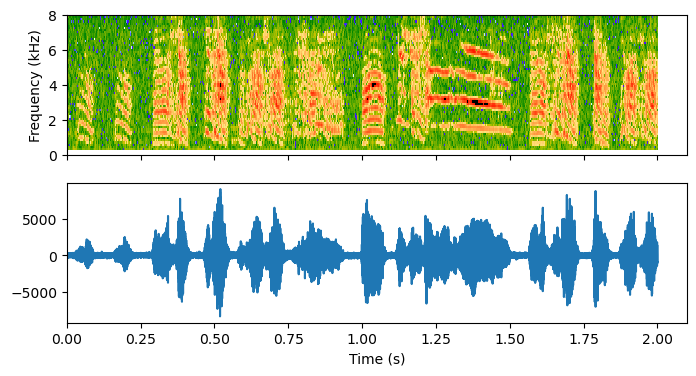

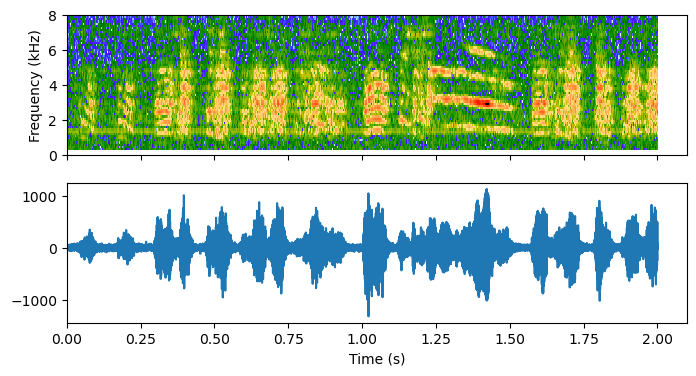

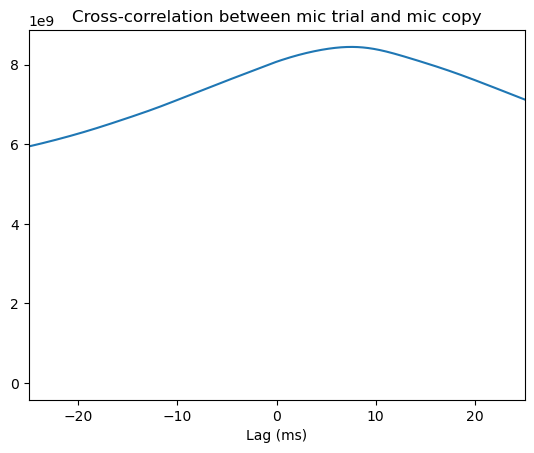

In [6]:
# Choose a ramdom trial
trial = trials.sample().iloc[0]
mic_trial, mic_copy = get_mic_data(nwb, trial)
rate = nwb.acquisition['audio'].rate

# Spectrogram paramteters.
stim_params = {}
stim_params['fband'] = 120
stim_params['nstd'] = 6
stim_params['high_freq'] = 8000
stim_params['low_freq'] = 250
stim_params['log'] = 1
stim_params['stim_rate'] = 1000  # Sample rate of spectrogram


# First figure for the microphone copy
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=100, figsize = (8,4))

tfrep = timefreq_raw(mic_copy, rate, 'ft', params=stim_params)

minSpect = tfrep['spec'].max()-DBNOISE
maxB = tfrep['spec'].max()
ax1.imshow(tfrep['spec'], extent=[tfrep['t'][0], tfrep['t'][-1], tfrep['f'][0]*1e-3, tfrep['f'][-1]*1e-3],
                aspect='auto', interpolation='nearest', origin='lower', cmap=cmap, vmin=minSpect, vmax=maxB)
ax1.set_ylim(0, 8)
ax1.set_ylabel('Frequency (kHz)')

tval = np.arange(stop=len(mic_copy))/rate
ax2.plot(tval, mic_copy)
ax2.set_xlabel('Time (s)')

# Second copy for the microphone 
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=100, figsize = (8,4))

tfrep = timefreq_raw(mic_trial, rate, 'ft', params=stim_params)
minSpect = tfrep['spec'].max()-DBNOISE
maxB = tfrep['spec'].max()
ax1.imshow(tfrep['spec'], extent=[tfrep['t'][0], tfrep['t'][-1], tfrep['f'][0]*1e-3, tfrep['f'][-1]*1e-3],
                aspect='auto', interpolation='nearest', origin='lower', cmap=cmap, vmin=minSpect, vmax=maxB)
ax1.set_ylim(0, 8)
ax1.set_ylabel('Frequency (kHz)')

tval = np.arange(stop=len(mic_trial))/rate
ax2.plot(tval, mic_trial)
ax2.set_xlabel('Time (s)')

# plot the cross-correlation between the two microphone signals
from scipy.signal import correlate
from soundsig.signal import lowpass_filter, highpass_filter
n = len(mic_trial)
fmax = (n+1)//2
fNyq = rate/2
corr = correlate(lowpass_filter(np.abs(highpass_filter(mic_trial, rate, 500)), rate, 150), lowpass_filter(np.abs(highpass_filter(mic_copy, rate, 500)), rate, 150), mode='full')
lags = np.arange(-len(mic_trial)+1, len(mic_copy))
plt.figure()
plt.plot(1000*lags/rate, corr)
plt.xlim(-25, 25)
plt.xlabel('Lag (ms)')
plt.title('Cross-correlation between mic trial and mic copy')



### Create an stimulus-response data set (srData) per stimlus

/Users/frederictheunissen/opt/anaconda3/envs/strf/lib/python3.9/site-packages/hdmf/spec/namespace.py:583: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.7.0, loaded version: 2.8.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


              kilosort_dir  kilosort_id group       ks_x      ks_y   
id                                                                   
2   ks4_lat_250215/shank_0            3  good  18.334148  53.16732  \

                                          spike_times electrodes  
id                                                                
2   [0.20636666666666667, 0.23453333333333334, 0.2...       [21]  


/Users/frederictheunissen/Code/strfPy/module/strfpy/timeFreq.py:29: RuntimeWarning: divide by zero encountered in log10
  normedS = 20 * np.log10(normedS)
/Users/frederictheunissen/opt/anaconda3/envs/strf/lib/python3.9/site-packages/soundsig/sound.py:541: UserWarning: Overwriting the cmap 'SpectroColorMap' that was already in the registry.
  mpl.colormaps.register(cmap=spec_cmap, force=True)


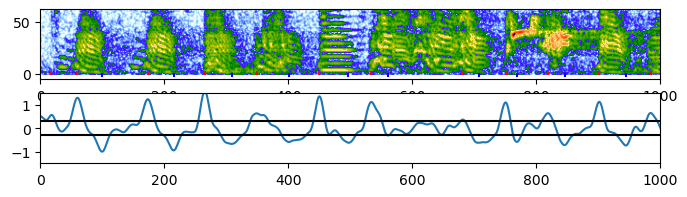

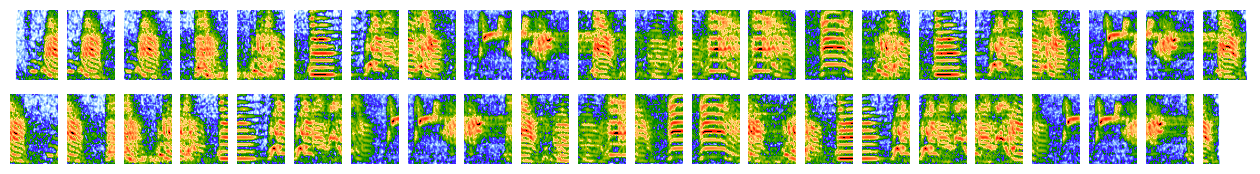

This playback stim-response data set has 26 stimuli.


In [7]:
# Preprocess sound stimulus and segment

respChunkLen = 100 # ms of stim to use in each chunk of feature space
segmentBuffer = 30 # ms to add at the beginning of each segment
nLaguerre = 25 # number of laguerre functions to use
feature = 'spect_windows'
event_types = 'onoff_feature'
nPoints = 150 # number of points to use in the kernel

srData = preprocSound.preprocess_sound_nwb(nwb_file, 'playback_trials', unit.name, preprocess_type='ft')
calcSegmentedModel.preprocess_srData(srData, plot=False, respChunkLen=respChunkLen, segmentBuffer=segmentBuffer, tdelta=0, plotFlg = True, derivativeThresh=0.3)

print('This playback stim-response data set has %d stimuli.' % (len(srData['datasets'])))


The single trial SNR with smoothing at 31 ms is 0.4993
The corresponding EV for 1 trials is 0.3330
The corresponding EV for 10 trials is 0.8331
The cumulative Information up to 500 Hz is 10.9344 bits/s
The total weight (data points used) is 694132


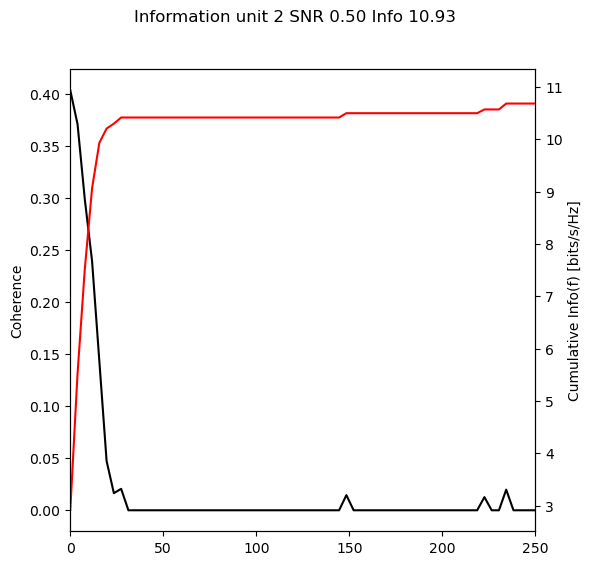

In [8]:
# Estimate the single trial SNR for this data set - should we use the same mean?
smWindow = 31  # smoothing window in ms
snrEst, f, snrEstf, cumInfo, totWeight = preprocSound.estimate_SNR(srData, smWindow=smWindow)
print('The single trial SNR with smoothing at %.0f ms is %.4f' % (smWindow, 
                                                                  snrEst))
print('The corresponding EV for 1 trials is %.4f' % (snrEst/(snrEst + 1)))
print('The corresponding EV for 10 trials is %.4f' % (10*snrEst/(10*snrEst + 1)))
print('The cumulative Information up to %.0f Hz is %.4f bits/s' % (f[-1], cumInfo[-1]))
print('The total weight (data points used) is %.0f' % (totWeight))

# Plot the SNRf and the Cumulative Information
figname = 'Information unit %s SNR %.2f Info %.2f' % (unit.name, snrEst, cumInfo[-1])
fig, ax1 = plt.subplots(1,1, dpi=100, figsize=(6,6))
fig.suptitle(figname)
ax1.plot(f, snrEstf/(snrEstf+1), 'k')
ax1.set_ylabel('Coherence')
# ax1.set_yscale('log')
ax2 = ax1.twinx()
ax2.plot(f, cumInfo, 'r')
ax2.set_ylabel('Cumulative Info(f) [bits/s/Hz]')
ax2.set_xlabel('Frequency (Hz)')    
ax2.set_xlim([0, f[-1]/2])
plt.savefig('/Users/frederictheunissen/Desktop/SNRf_cumInfo.eps', dpi=100)


In [9]:
r2num = 0
r2den = 0
for pair in srData["datasets"]:
    yw = pair["resp"]["weights"]
    r2num += np.sum(snrEst*yw)
    r2den += np.sum(1+snrEst*yw)

EV = r2num/r2den
print('The corresponding average EV for this data set is %.4f' % (EV))



The corresponding average EV for this data set is 0.8702


In [10]:
# Calculate the average response at onsets and offsets

meansOnOff = np.zeros((2,nPoints))
nEventsOnOff = np.zeros((2,nPoints))
responseAvg = 0
stimLenTot = 0
for ds in srData['datasets']:
    events = ds['events']
    nEvents = len(events['index'])
    y = ds['resp']['psth_smooth']
    if "weights" not in ds["resp"]:
        yw = np.ones_like(y)
    else:
        yw =ds["resp"]["weights"]
    y = y[yw > 0]
    yw = yw[yw > 0]

    responseAvg += np.sum(y*yw)
    stimLenTot += np.sum(yw)
    stimLen = len(yw)
    for iEvent in range(nEvents):
        startInd = events['index'][iEvent]        
        if (startInd >= stimLen):
            break

        endInd = startInd + nPoints
        if (endInd>stimLen):
            endInd = stimLen
            
        if (events['onoff_feature'][iEvent][0] == 1 ):
            meansOnOff[0,0:endInd-startInd] = meansOnOff[0,0:endInd-startInd] + y[startInd:endInd]*yw[startInd:endInd]
            nEventsOnOff[0,0:endInd-startInd] += yw[startInd:endInd]
        else:
            meansOnOff[1,0:endInd-startInd] = meansOnOff[1,0:endInd-startInd] + y[startInd:endInd]*yw[startInd:endInd]
            nEventsOnOff[1,0:endInd-startInd] += yw[startInd:endInd]

meansOnOff[0,:] /= nEventsOnOff[0,:]
meansOnOff[1,:] /= nEventsOnOff[1,:]
responseAvg /= stimLenTot

meansOnOff[0,:] -= responseAvg
meansOnOff[1,:] -= responseAvg




In [11]:
# Fit the segmentation (on-off here) kernel (impulse response)
segModel0 = calcSegmentedModel.fit_seg(srData, nPoints, x_feature = event_types, y_feature = 'psth_smooth', kernel = 'Kernel0', nD=2, tol=np.array([0.1, 0.01, 0.001, 0.0001]), store_error = True )
learned_conv_kernel0 = segModel0['weights'].reshape(2, nPoints)

In [12]:
print(np.max(segModel0['R2CV']))

0.10341044109302988


In [13]:
raw_kernel0 = segModel0['Cxy'].reshape(2, nPoints)
b0_0 = segModel0['b0']
Cxx_0 = segModel0['Cxx']

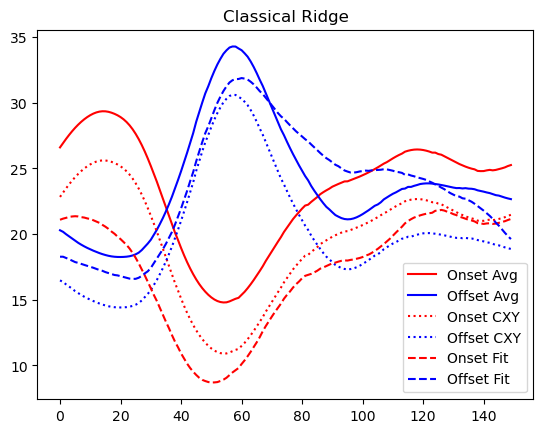

In [14]:
# Checking to see if our normalization works properfly

plt.plot(meansOnOff[0,:]+responseAvg, 'r', label='Onset Avg')
plt.plot(meansOnOff[1,:]+responseAvg, 'b', label='Offset Avg')
plt.plot(raw_kernel0[0,:]*1/np.diag(Cxx_0)[0:nPoints]+b0_0, 'r:', label='Onset CXY')
plt.plot(raw_kernel0[1,:]*1/np.diag(Cxx_0)[nPoints:]+b0_0, 'b:', label='Offset CXY')
plt.plot(learned_conv_kernel0[0,:]+b0_0, 'r--', label='Onset Fit')
plt.plot(learned_conv_kernel0[1,:]+b0_0, 'b--', label='Offset Fit')
plt.title('Classical Ridge')
plt.legend()


In [15]:
# Fit the segmentation (on-off here) kernel (impulse response)
segModel = calcSegmentedModel.fit_seg(srData, nPoints, x_feature = event_types, y_feature = 'psth_smooth', kernel = 'Kernel', nD=2, tol=np.array([0.1, 0.01, 0.001, 0.0001]), store_error = True )
learned_conv_kernel = segModel['weights'].reshape(2, nPoints)

In [16]:
print(np.max(segModel['R2CV']))

0.10311183208699626


In [17]:
raw_kernel = segModel['Cxy'].reshape(2, nPoints)
b0 = segModel['b0']
Cxx = segModel['Cxx']

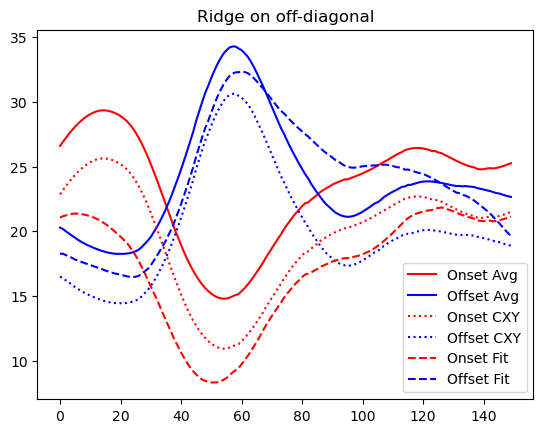

In [18]:
# Checking to see if our normalization works properfly

plt.plot(meansOnOff[0,:]+responseAvg, 'r', label='Onset Avg')
plt.plot(meansOnOff[1,:]+responseAvg, 'b', label='Offset Avg')
plt.plot(raw_kernel[0,:]*1/np.diag(Cxx)[0:nPoints]+b0, 'r:', label='Onset CXY')
plt.plot(raw_kernel[1,:]*1/np.diag(Cxx)[nPoints:]+b0, 'b:', label='Offset CXY')
plt.plot(learned_conv_kernel[0,:]+b0, 'r--', label='Onset Fit')
plt.plot(learned_conv_kernel[1,:]+b0, 'b--', label='Offset Fit')
plt.title('Ridge on off-diagonal')
plt.legend()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


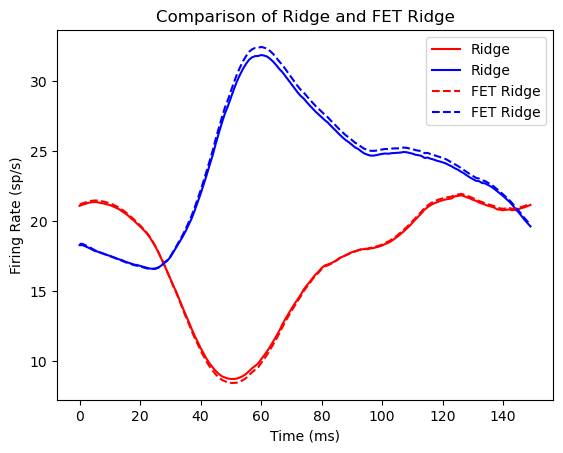

In [19]:
plt.plot(learned_conv_kernel0[0,:]+b0_0, 'r', label='Ridge')
plt.plot(learned_conv_kernel0[1,:]+b0_0, 'b', label='Ridge')
plt.plot(learned_conv_kernel[0,:]+b0+0.1, 'r--', label='FET Ridge')
plt.plot(learned_conv_kernel[1,:]+b0+0.1, 'b--', label='FET Ridge')
plt.legend()
plt.title('Comparison of Ridge and FET Ridge')
plt.xlabel('Time (ms)')
plt.ylabel('Firing Rate (sp/s)')
plt.savefig('/Users/frederictheunissen/Desktop/Comparison_Ridge_FET_Ridge.eps', dpi=100)

In [20]:
# Fit the segmentation (on-off here) kernel2 (impulse response with alternative matrix inversion)
segModel2 = calcSegmentedModel.fit_seg(srData, nPoints, x_feature = event_types, y_feature = 'psth_smooth', kernel = 'Kernel2', nD=2, tol=np.array([10.0, 1.0, 0.1, 0.01, 0.001, 0.0001]), store_error = True )
learned_conv_kernel2 = segModel2['weights'].reshape(2, nPoints)

In [21]:
raw_kernel2 = segModel2['Cxy'].reshape(2, nPoints)
b0_2 = segModel2['b0']
Cxx_2 = segModel2['Cxx']

In [22]:
print(segModel['R2CV'])
print(segModel2['R2CV'])

[0.10119096 0.10311183 0.10297699 0.1029561 ]
[0.10107219 0.10334333 0.10301043 0.10295956 0.10295427 0.10295374]


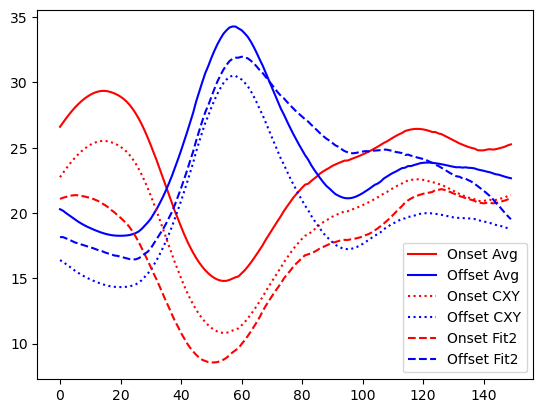

In [23]:
# Checking to see if our normalization works properfly

plt.plot(meansOnOff[0,:]+responseAvg, 'r', label='Onset Avg')
plt.plot(meansOnOff[1,:]+responseAvg, 'b', label='Offset Avg')
plt.plot(raw_kernel2[0,:]*1/np.diag(Cxx)[0:nPoints]+b0_2, 'r:', label='Onset CXY')
plt.plot(raw_kernel2[1,:]*1/np.diag(Cxx)[nPoints:]+b0_2, 'b:', label='Offset CXY')
plt.plot(learned_conv_kernel2[0,:]+b0_2, 'r--', label='Onset Fit2')
plt.plot(learned_conv_kernel2[1,:]+b0_2, 'b--', label='Offset Fit2')
plt.legend()

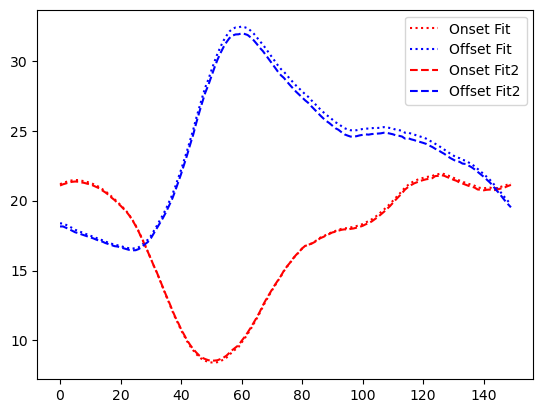

In [24]:
plt.plot(learned_conv_kernel[0,:]+0.1+b0, 'r:', label='Onset Fit')
plt.plot(learned_conv_kernel[1,:]+0.1+b0, 'b:', label='Offset Fit')
plt.plot(learned_conv_kernel2[0,:]+b0_2, 'r--', label='Onset Fit2')
plt.plot(learned_conv_kernel2[1,:]+b0_2, 'b--', label='Offset Fit2')
plt.legend()

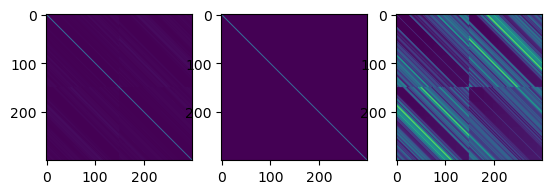

In [25]:
# Make plots of stimulus autocorrelation matrix for figures, etc
Cxx = segModel['Cxx']
Cxx_corr = Cxx - np.diag(np.diag(Cxx))
plt.subplot(1,3,1)
plt.imshow(Cxx)
plt.subplot(1,3,2)
plt.imshow(np.diag(np.diag(Cxx)))
plt.subplot(1,3,3)
plt.imshow(Cxx_corr)


Norm of offdiagonal correction 0.023261


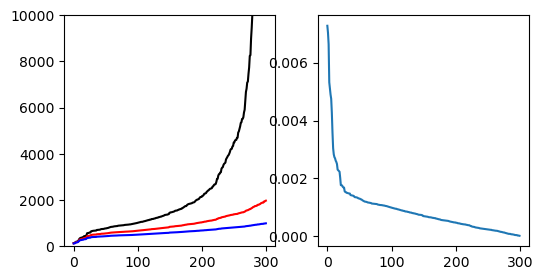

In [26]:
u, s, v = np.linalg.svd(Cxx_corr)
print('Norm of offdiagonal correction %f' % np.linalg.norm(Cxx_corr))
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.plot(1/s, 'k')
plt.plot(1/(s + 0.0005), 'r')
plt.plot(1/(s + 0.001), 'b')
plt.ylim((0,10000))
plt.subplot(1,2,2)
plt.plot(s)

Norm of Cxx 0.165765


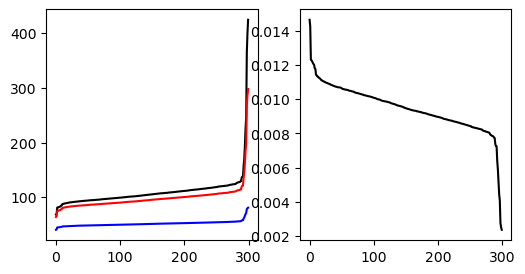

In [27]:
ua, sa, va = np.linalg.svd(Cxx)
print('Norm of Cxx %f' % np.linalg.norm(Cxx))
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.plot(1/sa, 'k')
plt.plot(1/(sa + 0.001), 'r')
plt.plot(1/(sa + 0.01), 'b')
plt.subplot(1,2,2)
plt.plot(sa, 'k')


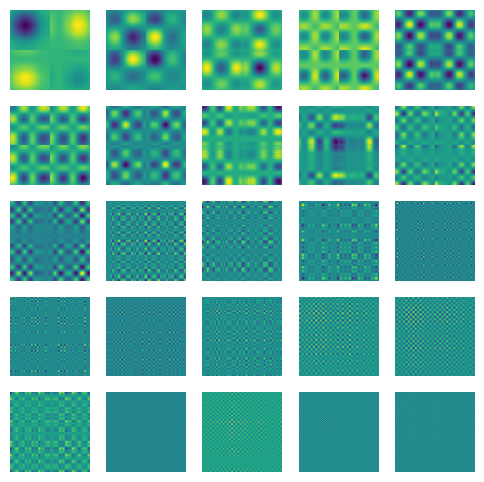

In [28]:
nPlots = 25
plt.figure(figsize=(6,6))
for ip in range(nPlots):
    plt.subplot(5,5, ip+1)
    u0 = np.reshape(u[:,ip], (u.shape[0], 1))
    v0 = np.reshape(v[ip,:], (1, v.shape[1]))
    Cxx_corrD = (u0@v0)*s[ip]
    ax = plt.imshow(Cxx_corrD)
    ax.axes.set_axis_off()



1.0014031102372956


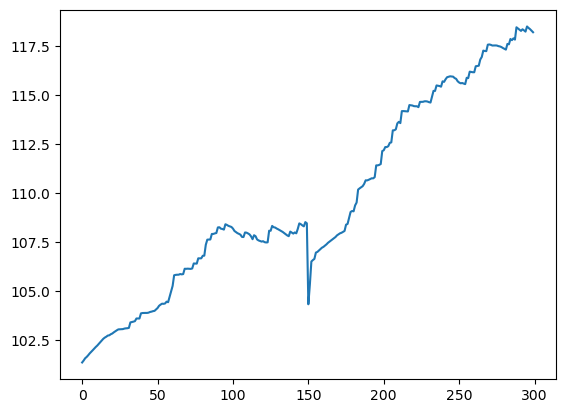

In [29]:
Cxx_inv = calcSegmentedModel.nearDiagInv(np.diag(np.diag(Cxx)), u, s, v, tol=0.01*np.linalg.norm(Cxx_corr) )
itest = Cxx_inv@Cxx
print(np.max(itest))
plt.plot(np.diag(Cxx_inv))

In [30]:
# Fit the on-off kernels with laguerre and DOGs
laguerre_args = calcSegmentedModel.fit_kernel_LG(learned_conv_kernel, nPoints, nD=2)
DOGS_args = calcSegmentedModel.fit_kernel_DG(learned_conv_kernel, nPoints, nD=2)

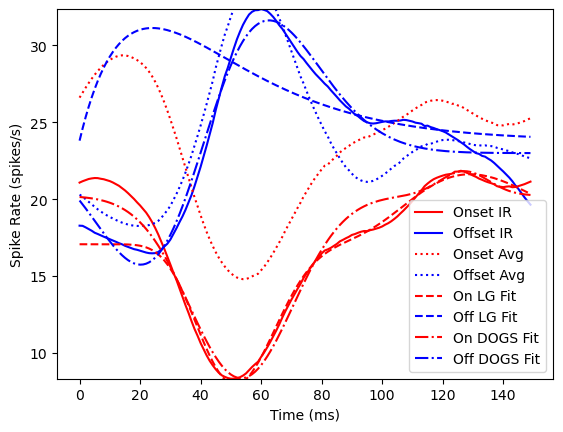

In [31]:
# Plot the segmented Kernels for this neuron and the laguerre fits
# b0 = segModel['yavg']
nt = learned_conv_kernel.shape[1]
x_t = np.arange(nt)
nLGFit = laguerre_args.shape[1]-2
yOnFitLG = np.ones(nt)*np.mean(learned_conv_kernel[0,:])
for iLG in range(nLGFit):
        yOnFitLG += calcSegmentedModel.laguerre(x_t, amp=laguerre_args[0,2+iLG], tau=laguerre_args[0,0], alpha=laguerre_args[0,1], xorder=iLG)

yOffFitLG = np.ones(nt)*np.mean(learned_conv_kernel[1,:])
for iLG in range(nLGFit):
        yOffFitLG += calcSegmentedModel.laguerre(x_t, amp=laguerre_args[1,2+iLG], tau=laguerre_args[1,0], alpha=laguerre_args[1,1], xorder=iLG)

yOnDOGFit = calcSegmentedModel.dogs(np.arange(nt), *DOGS_args[0,:])
yOffDOGFit = calcSegmentedModel.dogs(np.arange(nt), *DOGS_args[1,:])

plt.figure()

plt.plot(learned_conv_kernel[0,:]+b0, 'r', label='Onset IR')
plt.plot(learned_conv_kernel[1,:]+b0, 'b', label='Offset IR')
plt.plot(meansOnOff[0,:]+responseAvg, 'r:', label='Onset Avg')
plt.plot(meansOnOff[1,:]+responseAvg, 'b:', label='Offset Avg')
plt.plot(yOnFitLG+b0, 'r--', label='On LG Fit')
plt.plot(yOffFitLG+b0, 'b--', label='Off LG Fit')
plt.plot(yOnDOGFit+b0, 'r-.', label='On DOGS Fit')
plt.plot(yOffDOGFit+b0, 'b-.', label='Off DOGS Fit')
plt.xlabel('Time (ms)')
plt.ylabel('Spike Rate (spikes/s)')
plt.ylim((np.min(learned_conv_kernel+b0), np.max(learned_conv_kernel+b0)))
plt.legend()

Tau = 6.40 Alpha = 11.88


Text(0, 0.5, 'Spike Rate (spikes/s)')

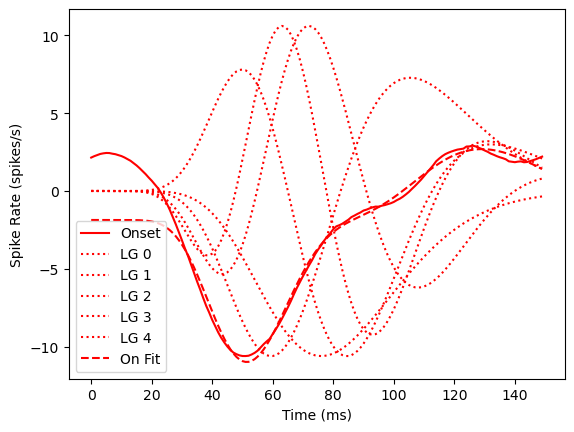

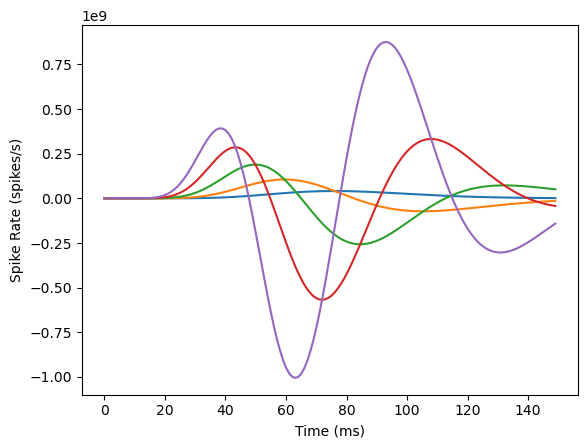

In [32]:
# Show how the fit is done for the LG - note that it is even worse than it looks because basis fit componnents are scaled.
nt = learned_conv_kernel.shape[1]
x_t = np.arange(nt)
nLGFit = laguerre_args.shape[1]-2
yOnFit = np.ones(nt)*np.mean(learned_conv_kernel[0,:])
plt.plot(learned_conv_kernel[0,:], 'r', label='Onset')
for iLG in range(nLGFit):
        yLG = calcSegmentedModel.laguerre(x_t, amp=laguerre_args[0,2+iLG], tau=laguerre_args[0,0], alpha=laguerre_args[0,1], xorder=iLG)
        yOnFit += yLG
        plt.plot(yLG*np.max(np.abs(learned_conv_kernel[0,:]))/np.max(np.abs(yLG)), 'r:', label='LG %d'%(iLG))

plt.plot(yOnFit, 'r--', label='On Fit')
plt.xlabel('Time (ms)')
plt.ylabel('Spike Rate (spikes/s)')
plt.legend()

plt.figure()
for iL in range(nLGFit):
    yLG = calcSegmentedModel.laguerre(
        x_t,
        amp=1.0,
        tau=laguerre_args[0,0],
        alpha=laguerre_args[0,1],
        xorder=iL,
        )
    plt.plot(yLG)
        
print('Tau = %.2f Alpha = %.2f' % (laguerre_args[0,0], laguerre_args[0,1]) )
plt.xlabel('Time (ms)')
plt.ylabel('Spike Rate (spikes/s)')

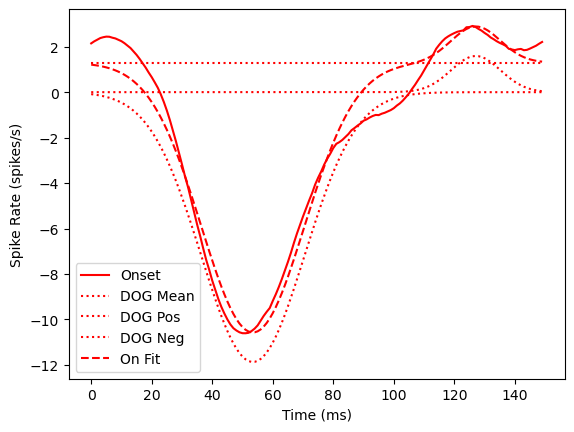

In [33]:
# Show how the fit is done for the DOGS 
nt = learned_conv_kernel.shape[1]
x_t = np.arange(nt)
nDOGS = 5

plt.plot(learned_conv_kernel[0,:], 'r', label='Onset')

meanValOn, ampPosOn, ampNegOn, tPosOn, tNegOn, sdPosOn, sdNegOn = DOGS_args[0]  

yOnFit = np.ones(nt)*meanValOn  
plt.plot(yOnFit, 'r:', label='DOG Mean')
yDG = ampPosOn*calcSegmentedModel.Gauss(x_t, tPosOn, sdPosOn)
plt.plot(yDG, 'r:', label='DOG Pos')
yOnFit += yDG
yDG = -ampNegOn*calcSegmentedModel.Gauss(x_t, tNegOn, sdNegOn)
plt.plot(yDG, 'r:', label='DOG Neg')
yOnFit += yDG

plt.plot(yOnFit, 'r--', label='On Fit')
plt.xlabel('Time (ms)')
plt.ylabel('Spike Rate (spikes/s)')
plt.legend()



In [34]:
# first use PCA to reduce dim of the features'
pca_spect = calcSegmentedModel.generate_event_pca_feature(srData, event_types, feature, pca = None, npcs=20)
feature2 = 'mps_windows'
pca_mps = calcSegmentedModel.generate_event_pca_feature(srData, event_types, feature2, pca = None, npcs=20)

### The Segmented Laguerre

In [35]:
# Calculate the segmented encoding models for spectrograms and Laguerre.
nLaguerre = 20
segIDModelLG = calcSegmentedModel.fit_seg(srData, nPoints, feature, y_feature = 'error_Kernel', y_R2feature = 'psth_smooth', kernel = 'LG', basis_args =laguerre_args, nD=nLaguerre )

print('Laguerre model based on segmented Log Spect on PSHT')
print('R2 CV for Seg: %.4f' % (np.max(segModel['R2CV'])))
print('R2 CV for Seg+Id: %.4f' % (np.max(segIDModelLG['R2CV'])))
evOne= snrEst/(snrEst + 1)
print('EV : %.4f' % (EV))



Laguerre model based on segmented Log Spect on PSHT
R2 CV for Seg: 0.1031
R2 CV for Seg+Id: 0.4925
EV : 0.8702


In [36]:
# Calculate the segmented encoding models for mps and Laguerre.
nLaguerre = 20
segIDModelLGMPS = calcSegmentedModel.fit_seg(srData, nPoints, feature2, y_feature = 'error_Kernel', y_R2feature = 'psth_smooth', kernel = 'LG', basis_args =laguerre_args, nD=nLaguerre) 

print('Laguerre model based on segmented Log Spect on PSHT')
print('R2 CV for Seg: %.4f' % (np.max(segModel['R2CV'])))
print('R2 CV for Seg+Id: %.4f' % (np.max(segIDModelLGMPS['R2CV'])))
evOne= snrEst/(snrEst + 1)
print('EV : %.4f' % (EV))


Laguerre model based on segmented Log Spect on PSHT
R2 CV for Seg: 0.1031
R2 CV for Seg+Id: 0.3000
EV : 0.8702


/var/folders/zn/qkxxn59x2712k0l7j64f7ry40000gn/T/ipykernel_87595/785575512.py:32: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 2), dpi=100)


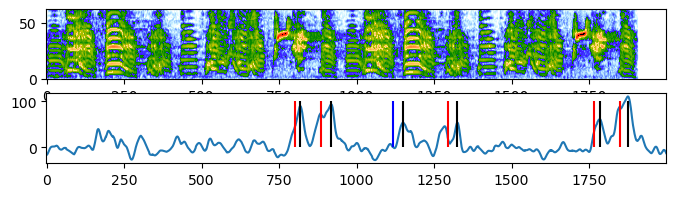

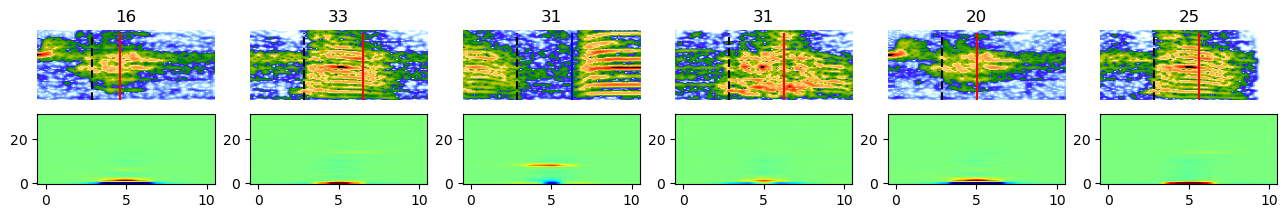

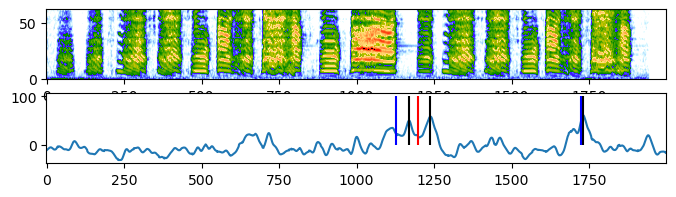

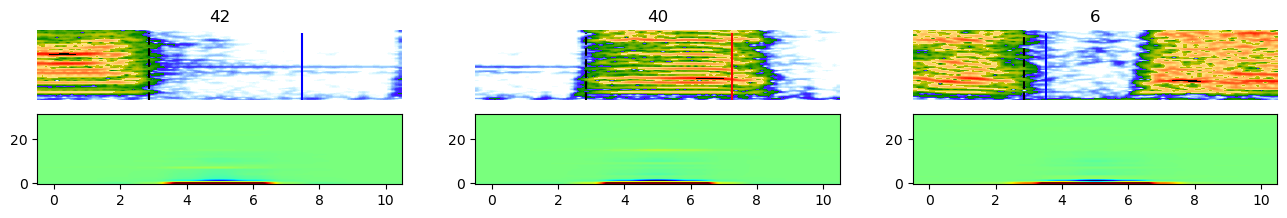

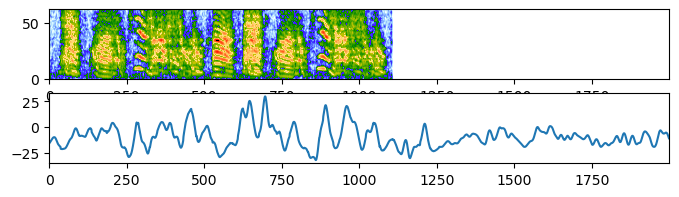

<Figure size 1600x200 with 0 Axes>

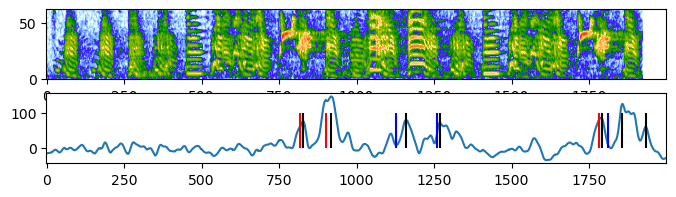

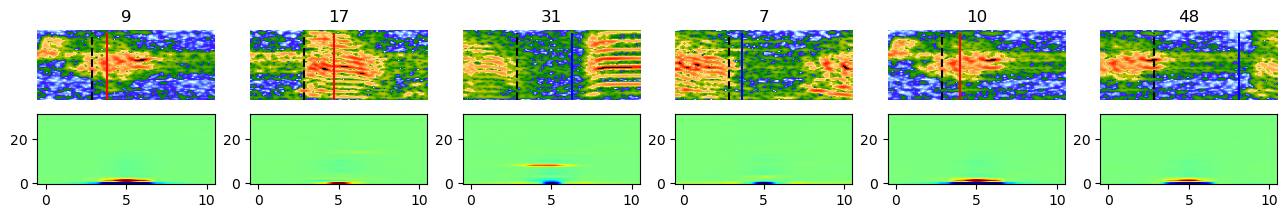

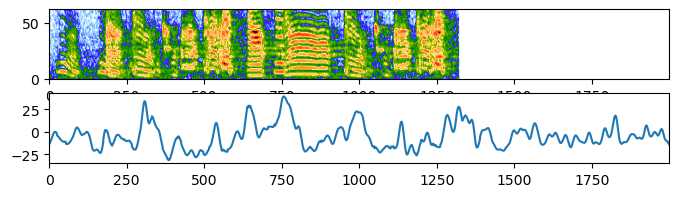

<Figure size 1600x200 with 0 Axes>

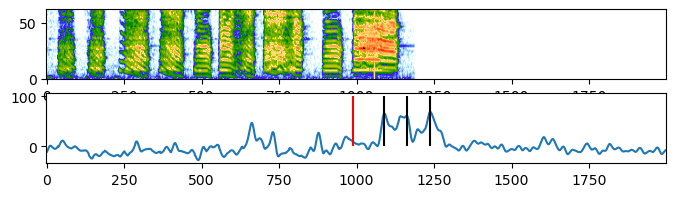

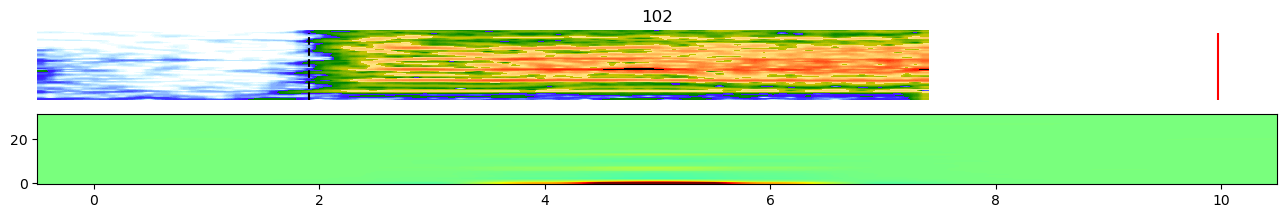

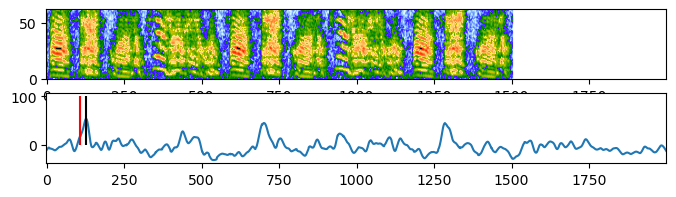

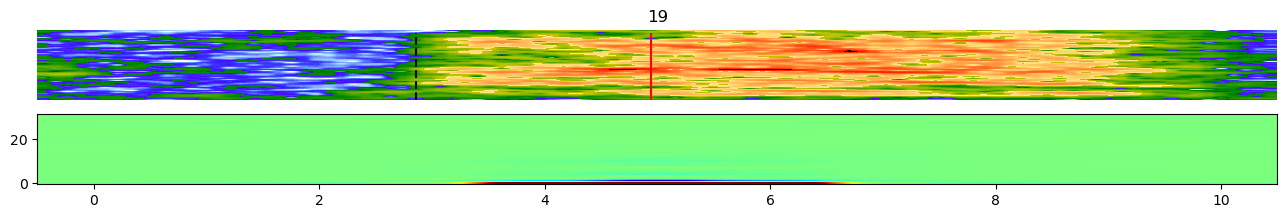

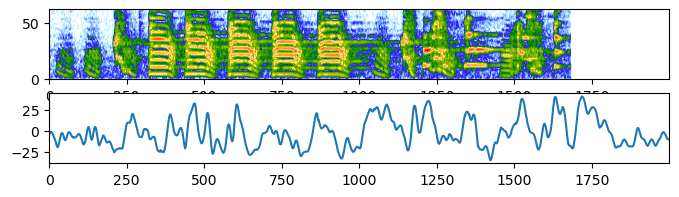

<Figure size 1600x200 with 0 Axes>

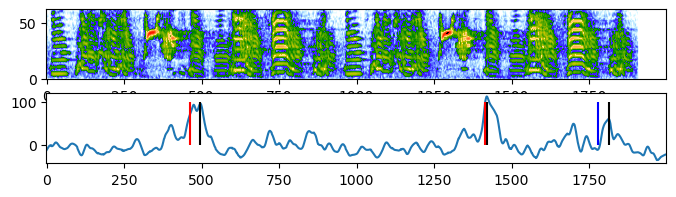

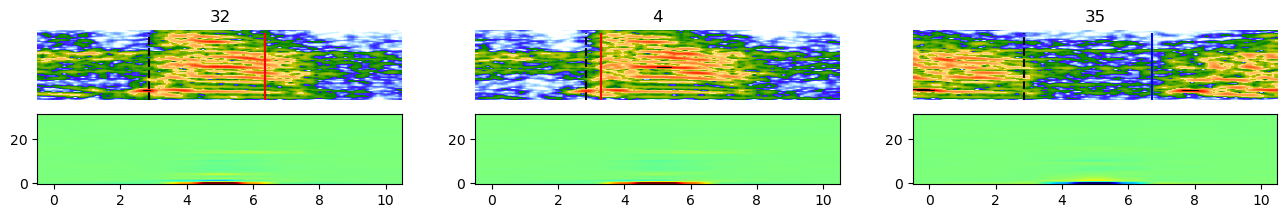

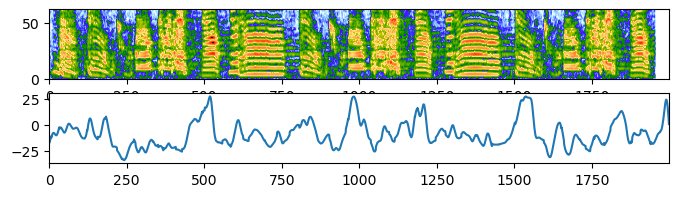

<Figure size 1600x200 with 0 Axes>

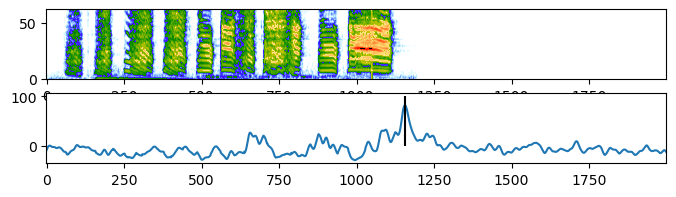

<Figure size 1600x200 with 0 Axes>

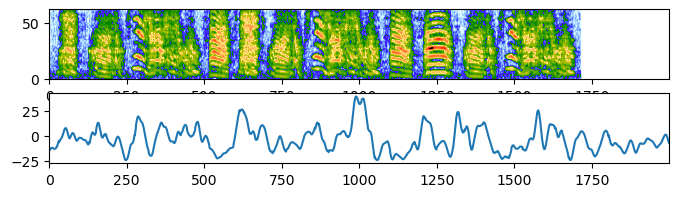

<Figure size 1600x200 with 0 Axes>

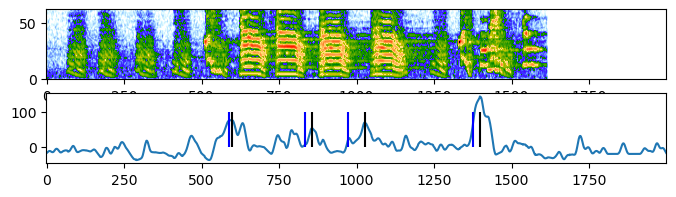

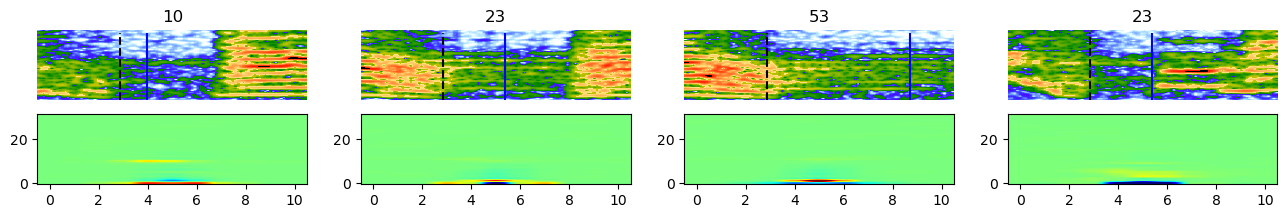

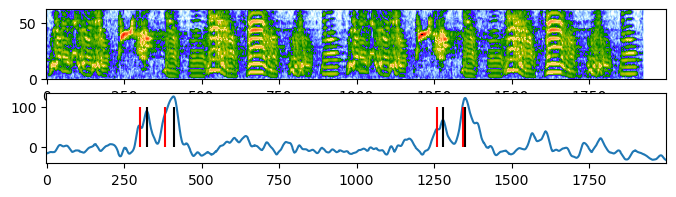

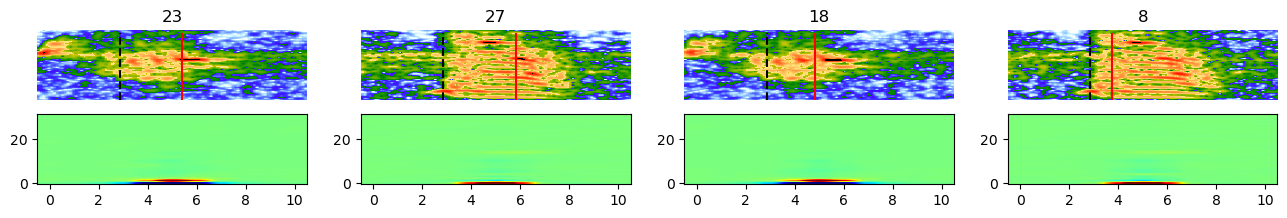

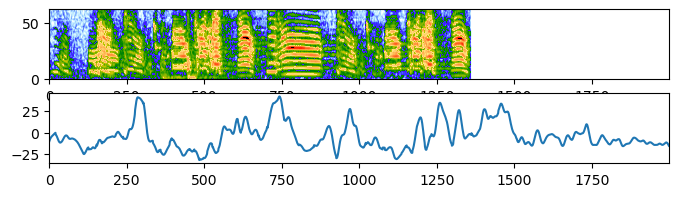

<Figure size 1600x200 with 0 Axes>

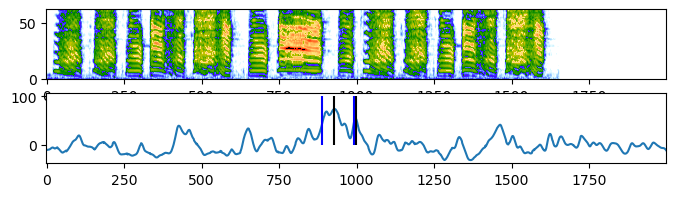

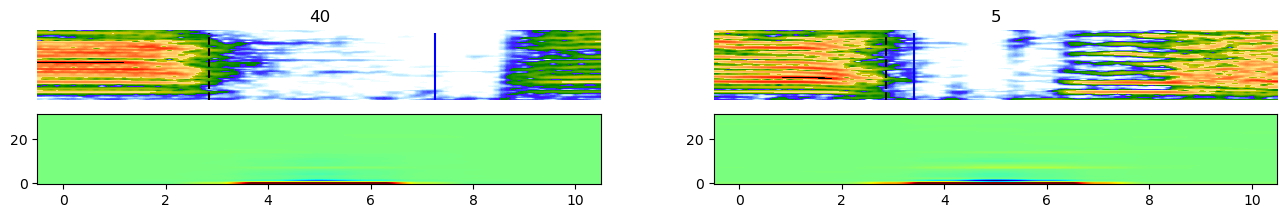

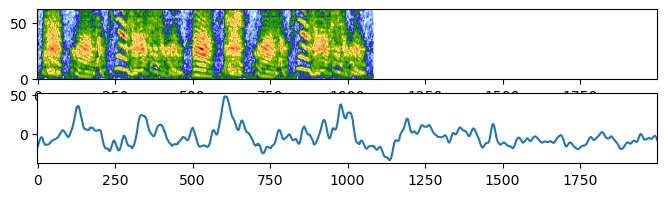

<Figure size 1600x200 with 0 Axes>

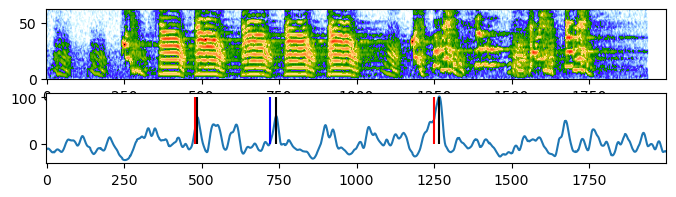

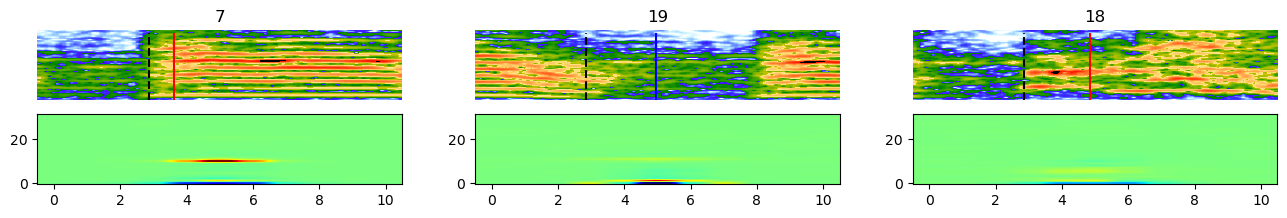

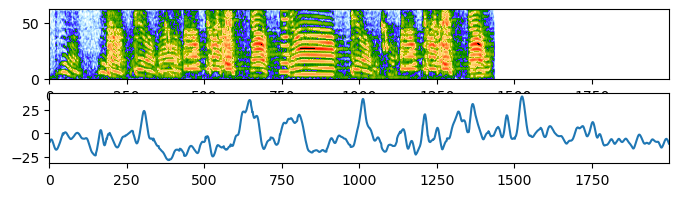

<Figure size 1600x200 with 0 Axes>

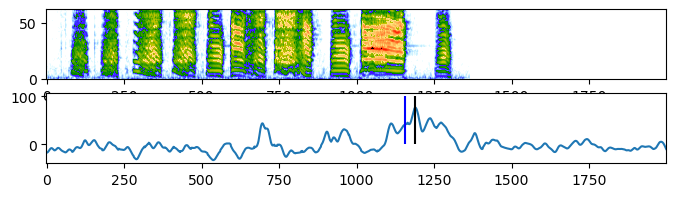

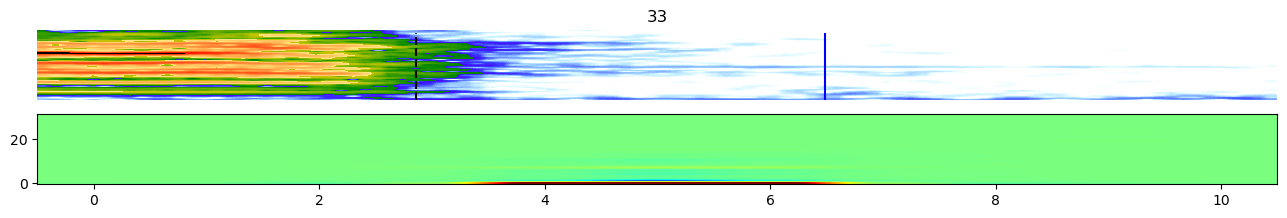

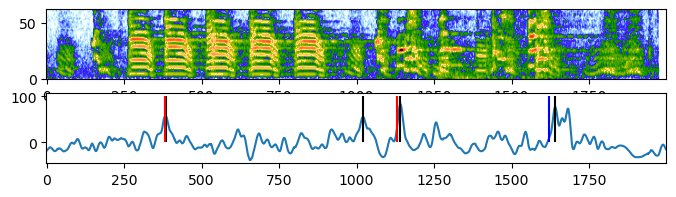

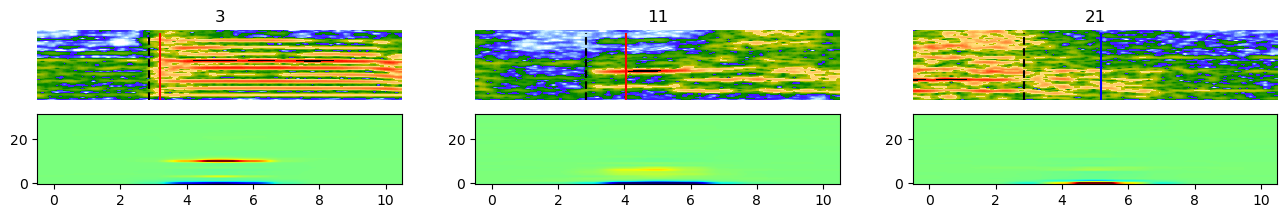

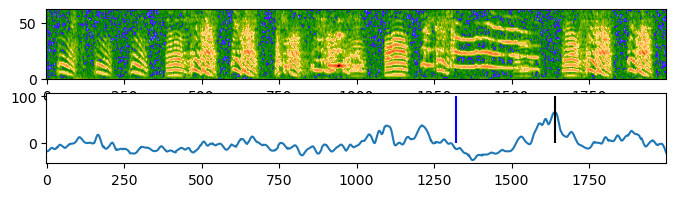

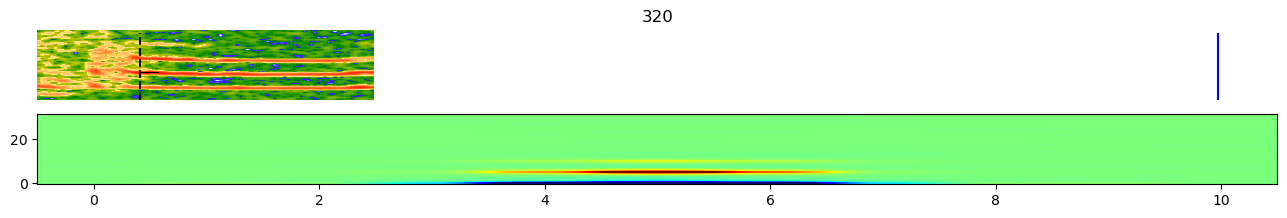

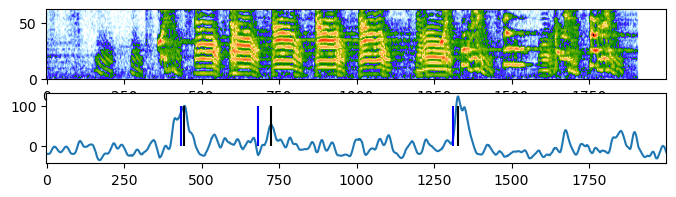

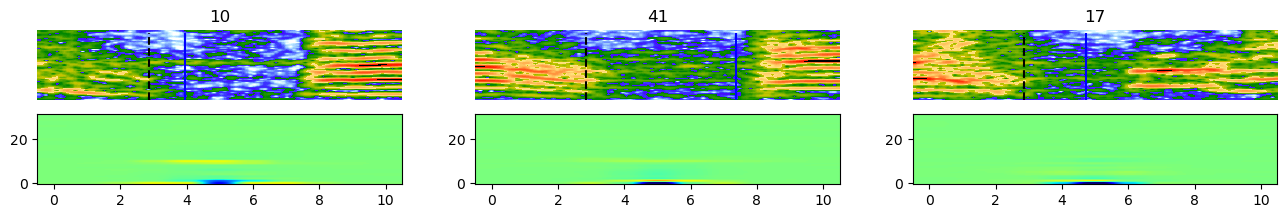

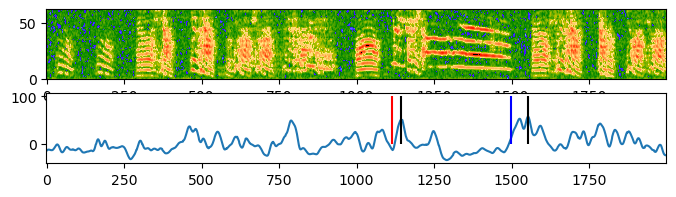

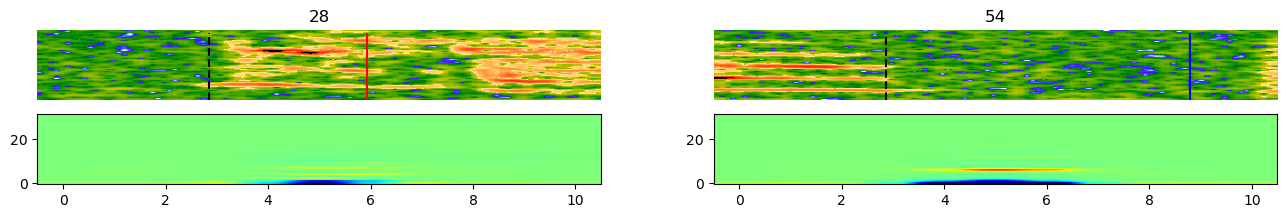

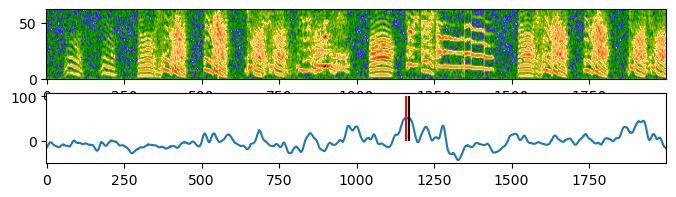

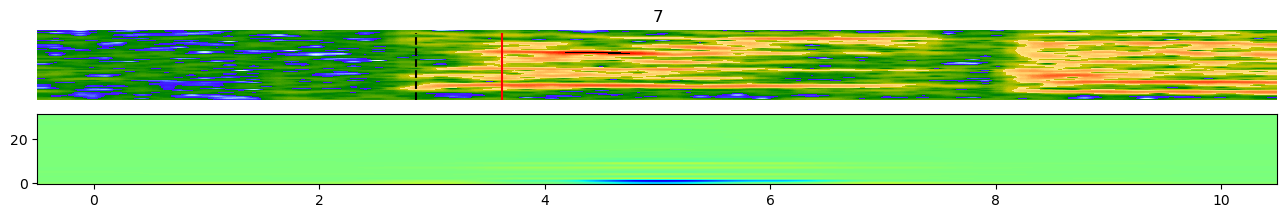

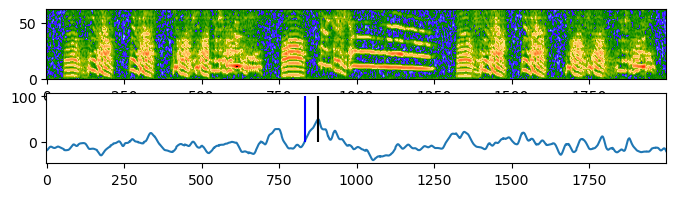

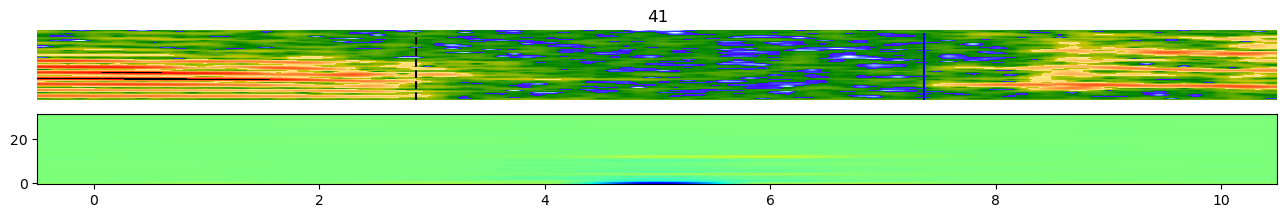

In [37]:
# Show where error is large for the segmentation only model
nb, nt = srData['datasets'][0]['events']['spect_windows'][0].shape
spectAvgOn = np.zeros((nb,nt))
spectAvgOff = np.zeros((nb,nt))
nOn = 0
nOff = 0

for ipair, pair in enumerate(srData['datasets']):

    # Find positive peaks in error
    pk_time, pk_property = find_peaks(pair['resp']['error_Kernel'], height= 50, distance= 50)
 
    # Match with event times
    events = pair['events']
    event_time = events['index']
    pk_event_time = []
    pk_index = []
    pk_dt = []
    for timePeak in pk_time:
        lastTime = 0
        for it, timeEvent in enumerate(event_time):
            if ( (lastTime < timePeak) & (timeEvent > timePeak) ):
                # print('Closest event preceeding peak error at %d is at %d dt = %d' % (timeEvent, lastTime, timeEvent-lastTime))
                pk_event_time.append(lastTime)
                pk_index.append(it-1)
                pk_dt.append(timePeak-lastTime)
                break
            lastTime = timeEvent

    pk_event_time = np.array(pk_event_time)

    plt.figure(figsize=(8, 2), dpi=100)

    plt.subplot(2, 1, 1)
    spectro = pair['stim']['tfrep']['spec']
    plt.imshow(spectro, aspect="auto", cmap=cmap, origin="lower")
            
    xlim = plt.xlim()
    plt.subplot(2, 1, 2)
    plt.plot(pair['resp']['error_Kernel'])
    plt.vlines(pk_time, 0, 100, 'k')
    for ipk_index in pk_index:
        if (events['onoff_feature'][ipk_index][0] == 1 ):
            plt.vlines(events['index'][ipk_index], 0, 100, 'r')
        else:
            plt.vlines(events['index'][ipk_index], 0, 100, 'b')
    plt.xlim(xlim)

    plt.figure(figsize=(16, 2), dpi=100)

    nEvents = pk_event_time.shape[0]
    for iEvent in range(nEvents):
        indEvent = pk_index[iEvent]
        plt.subplot(2, nEvents, iEvent+1)
        plt.imshow(events['spect_windows'][indEvent,:,:], aspect="auto", cmap=cmap, origin="lower")
        plt.vlines(30, 0, 60, 'k', linestyles='--')
        if (events['onoff_feature'][indEvent][0] == 1 ):
            plt.vlines(pk_dt[iEvent]+30, 0, 60, 'r' )
            spectAvgOn += events['spect_windows'][indEvent]
            nOn += 1
        else:
            plt.vlines(pk_dt[iEvent]+30, 0, 60, 'b' )
            spectAvgOff += events['spect_windows'][indEvent]
            nOff += 1
        plt.title('%d' % (pk_dt[iEvent]))
        plt.axis('off')
        plt.subplot(2,nEvents, nEvents+iEvent+1)
        plt.imshow(events['mps_windows'][indEvent,:,:], aspect="auto", cmap='jet', origin="lower", clim=(-300,300))
        # print('MPS max %.3f min %.3f' % (events['mps_windows'][indEvent].max(), events['mps_windows'][indEvent].min()))



spectAvgOn /= nOn
spectAvgOff /= nOff


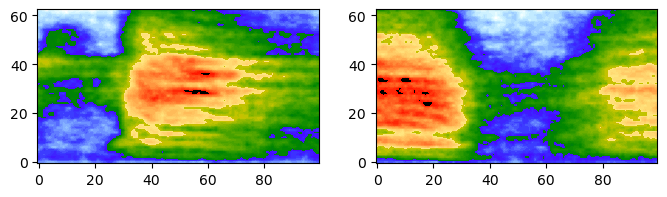

In [38]:
plt.figure(figsize=(8, 2), dpi=100)
plt.subplot(1,2,1)
plt.imshow(spectAvgOn, aspect="auto", cmap=cmap, origin="lower")
plt.subplot(1,2,2)
plt.imshow(spectAvgOff, aspect="auto", cmap=cmap, origin="lower")

### The Segmented DOGS

In [39]:
# Calculate the segmented encoding models for spectrograms and DOGS.
nDOGS = 5
segIDModelDG = calcSegmentedModel.fit_seg(srData, nPoints, feature, y_feature = 'error_Kernel', y_R2feature = 'psth_smooth', kernel = 'DG', basis_args =DOGS_args, nD=nDOGS) 

print('DOGS model based on segmented Log Spect on PSHT')
print('R2 CV for Seg: %.4f' % (np.max(segModel['R2CV'])))
print('R2 CV for Seg+Id: %.4f' % (np.max(segIDModelDG['R2CV'])))
print('EV : %.4f' % (EV))

DOGS model based on segmented Log Spect on PSHT
R2 CV for Seg: 0.1031
R2 CV for Seg+Id: 0.4870
EV : 0.8702


### The classic STRF

In [40]:
# Initialize the linear time invariant model. Here we choose 100 delay points 
nStimChannels = srData['nStimChannels']
strfLength = 200
strfDelays = np.arange(strfLength)
modelParams = strfSetup.linInit(nStimChannels, strfDelays)

# Convert srData into a format that strflab understands
allstim, allresp, allweights, groupIndex = strfSetup.srdata2strflab(srData, useRaw = False)
globDat = strfSetup.strfData(allstim, allresp, allweights, groupIndex)

# Additional model options
modelParams['Tol_val'] = [0.100, 0.050, 0.010, 0.005, 1e-03, 1e-04, 5e-05, 0]
modelParams['sparsenesses'] = [0, 1, 2, 3, 4, 5, 6, 7]
modelParams['setSep'] = 0
modelParams['timevary_PSTH'] = 0
modelParams['smooth_rt'] = 31
modelParams['ampsamprate'] = srData['stimSampleRate']
modelParams['respsamprate'] = srData['respSampleRate']
modelParams['infoFreqCutoff'] = 100
modelParams['infoWindowSize'] = 0.250
modelParams['TimeLagUnit'] = 'frame'
modelParams['outputPath'] = tempfile.gettempdir()
modelParams['TimeLag'] =  int(np.ceil(np.max(np.abs(modelParams['delays']))))


In [41]:
# Run direct fit optimization on all of the data
modelParams = trnDirectFit.trnDirectFit(modelParams, globDat)

Now calculating stim auto-correlation
The auto-correlation took 31.055204000000003 seconds.
Now calculating stim-response cross-correlation
Now doing cross-correlation calculation.
Done calculation of cross-correlation.
Now calculating JN cross-correlation.
Done calculation of JN cross-correlation.
The cross-correlation took 0.6869130000000041 seconds.
Calculating strfs for each tol value.
Done df_fft_AutoCrossCorr.
Calculating STRF for each tol value...
Now calculating STRF for tol_value: 0.1
Done calculation of STRF for tol_value: 0.1

Now calculating STRF for tol_value: 0.05
Done calculation of STRF for tol_value: 0.05

Now calculating STRF for tol_value: 0.01
Done calculation of STRF for tol_value: 0.01

Now calculating STRF for tol_value: 0.005
Done calculation of STRF for tol_value: 0.005

Now calculating STRF for tol_value: 0.001
Done calculation of STRF for tol_value: 0.001

Now calculating STRF for tol_value: 0.0001
Done calculation of STRF for tol_value: 0.0001

Now calculati

In [42]:
from scipy.signal import correlate, correlation_lags

In [43]:
stimB0 = allstim[:,0]
meanB0 = np.sum(stimB0*allweights)/np.sum(allweights)
meanR = np.sum(allresp*allweights)/np.sum(allweights)

ngroups = int(groupIndex.max()+1)
CS = np.zeros(399)
CSR = np.zeros(399)
CS_count = np.zeros(399)
CSR_count = np.zeros(399)

for igroup in range(ngroups):
    stimG = stimB0[groupIndex == igroup]
    respG = allresp[groupIndex == igroup]
    weightG = np.sqrt(allweights[groupIndex == igroup])

    corrSS = correlate((stimG-meanB0)*weightG, (stimG-meanB0)*weightG, mode="full")
    corrSR = correlate((stimG-meanB0), (respG-meanR)*weightG**2, mode="full")
    lags = correlation_lags(stimG.size, stimG.size, mode="full")
    xcorr_res = correlate(weightG, weightG, mode='full')
    xcorr_res2 = correlate(np.ones_like(weightG), weightG**2, mode='full')
    
    itlow = np.argwhere(lags == -199)[0][0]
    ithigh = np.argwhere(lags == 199)[0][0]+1

    CS += corrSS[itlow:ithigh]
    CSR += corrSR[itlow:ithigh]
    CS_count += xcorr_res[itlow:ithigh]
    CSR_count += xcorr_res2[itlow:ithigh]

CS /= CS_count
CSR /= CSR_count



In [44]:
modelParams[1]

{'outputDir': '/var/folders/zn/qkxxn59x2712k0l7j64f7ry40000gn/T',
 'tolerances': [0.1, 0.05, 0.01, 0.005, 0.001, 0.0001, 5e-05, 0],
 'sparsenesses': [0, 1, 2, 3, 4, 5, 6, 7]}

Text(0.5, 1.0, 'Cross-correlation')

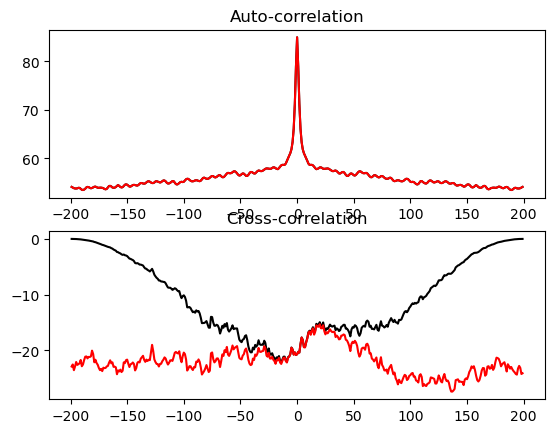

In [45]:
# Check the scale of the auto-correlation and cross-correlation

plt.subplot(2,1,1)
plt.plot(np.linspace(start= -199, stop= 199, num=399 ), modelParams[0]['CS'][0], 'k')
plt.plot(np.linspace(start= -199, stop= 199, num=399 ), CS, 'r')
plt.title('Auto-correlation')
plt.subplot(2,1,2)
plt.plot(np.linspace(start= -199, stop= 199, num=399 ), modelParams[0]['CSR'][0], 'k')
plt.plot(np.linspace(start= -199, stop= 199, num=399 ), CSR, 'r')
plt.title('Cross-correlation')


Text(0.5, 1.0, 'Power Spectrum')

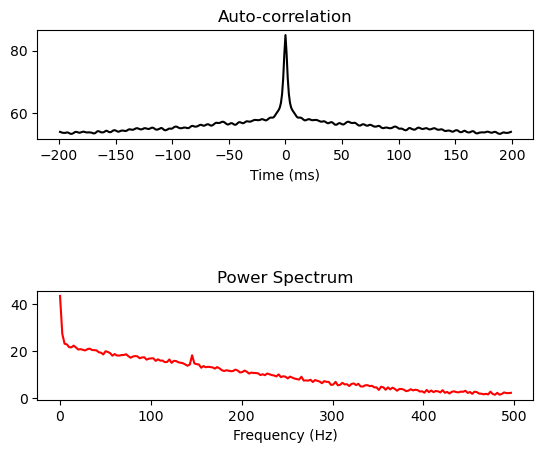

In [46]:
# Plot auto-correlation and power spectrum

plt.subplot(3,1,1)
plt.plot(np.linspace(start= -199, stop= 199, num=399 ), modelParams[0]['CS'][0], 'k')
plt.xlabel('Time (ms)')
plt.title('Auto-correlation')

powerCS = np.fft.rfft(modelParams[0]['CS'][0])
n = modelParams[0]['CS'][0].shape[0]
freq = np.fft.fftfreq(modelParams[0]['CS'][0].shape[0], d=0.001)

plt.subplot(3,1,3)
plt.plot(freq[0:int(n/2)], 10*np.log10(np.abs(powerCS)[0:int(n/2)]), 'r')
plt.xlabel('Frequency (Hz)')
plt.title('Power Spectrum')





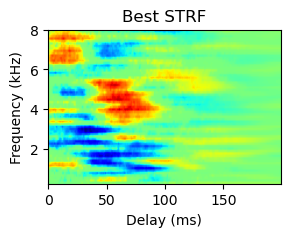

In [47]:
# display the best STRF
plt.figure(figsize=(3,2), dpi=100)

# Looks at first ds to examine frequencies
ds = srData['datasets'][0]
tfrep = ds['stim']['tfrep']
strfFrequencies = tfrep['f']

mySTRF = np.real(modelParams[0]['w1'])
maxabs = np.max(np.abs(mySTRF))

plt.imshow( mySTRF, origin='lower', cmap = 'jet', aspect='auto',
           extent=[strfDelays[0], strfDelays[-1], strfFrequencies[0]*1e-3, strfFrequencies[-1]*1e-3],
           vmin=-maxabs,
           vmax=maxabs)

plt.xlabel('Delay (ms)')
plt.ylabel('Frequency (kHz)')
plt.title('Best STRF')
plt.savefig('/Users/frederictheunissen/Desktop/best_STRF.eps', dpi=100)

In [59]:
nLaguerre

20

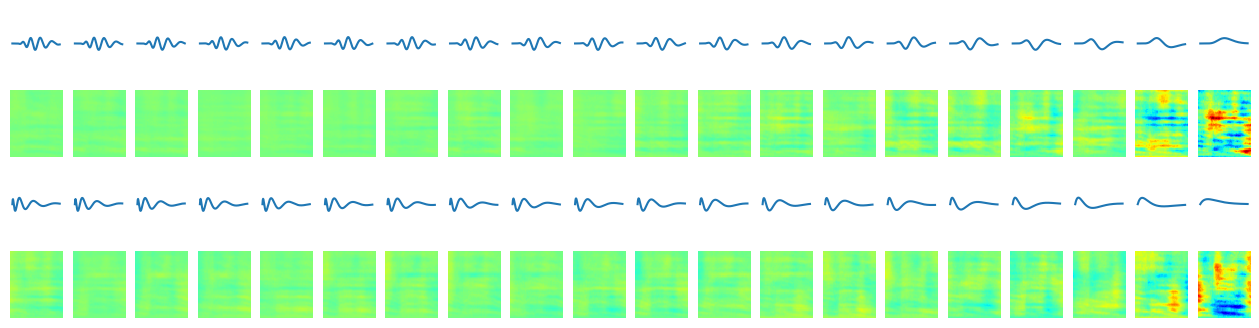

In [58]:
# Plot the On and Off filters for Laguerre Fit

# Get the sectrogram size
events = srData['datasets'][0]['events']
nf = events[feature].shape[1]
nt = events[feature].shape[2]
npcs = pca_spect.n_components_

plt.figure(figsize=(16, 4), dpi=100)
strfLGOn = np.zeros((nLaguerre, nf, nt))
strfLGOff = np.zeros((nLaguerre, nf, nt))
# x_t = np.arange(nt-segmentBuffer)
# x_plot = np.arange(nt)-segmentBuffer
x_t = np.arange(nPoints)

for iL in range(nLaguerre):
    istart = 2*npcs*iL
    iend = istart+npcs
    strfLGOn[iL,:,:] = np.dot(segIDModelLG['weights'][istart:iend], pca_spect.components_).reshape((nf,nt))
    strfLGOff[iL,:,:] = np.dot(segIDModelLG['weights'][istart+npcs:iend+npcs], pca_spect.components_).reshape((nf,nt))



maxSTRFOn = np.max((np.max(strfLGOn), np.abs(np.min(strfLGOn))))
maxSTRFOff = np.max((np.max(strfLGOff), np.abs(np.min(strfLGOff))))
maxSTRF = np.max((maxSTRFOn,maxSTRFOff))
                 
for iL in range(nLaguerre):
    yOn = np.zeros(nPoints)
    yOn = calcSegmentedModel.laguerre(
        x_t,
        amp=1.0,
        tau=laguerre_args[0,0],
        alpha=laguerre_args[0,1],
        xorder=iL,
        )
    yOn = yOn / np.sqrt(np.sum(yOn**2))
    yOff = np.zeros(nPoints)
    yOff = calcSegmentedModel.laguerre(
        x_t,
        amp=1.0,
        tau=laguerre_args[1,0],
        alpha=laguerre_args[1,1],
        xorder=iL,
        )
    yOff = yOff / np.sqrt(np.sum(yOff**2))
    plt.subplot(4,  nLaguerre, nLaguerre-iL)
    plt.plot(x_t,yOn)
    plt.ylim((-1,1))
    plt.axis('off')
    plt.subplot(4,  nLaguerre, 3*nLaguerre-iL)
    plt.plot(x_t,yOff)
    plt.ylim((-1,1))
    plt.axis('off')
    plt.subplot(4, nLaguerre, 2*nLaguerre-iL)
    plt.imshow(strfLGOn[iL,:,:], extent=[0, nt, tfrep['f'][0]*1e-3, tfrep['f'][-1]*1e-3],
                aspect='auto', interpolation='nearest', origin='lower', cmap='jet', vmin=-maxSTRF, vmax=maxSTRF)
    plt.axis('off')
    plt.subplot(4, nLaguerre, 4*nLaguerre-iL)
    plt.imshow(strfLGOff[iL,:,:], extent=[0, nt, tfrep['f'][0]*1e-3, tfrep['f'][-1]*1e-3],
                aspect='auto', interpolation='nearest', origin='lower', cmap='jet', vmin=-maxSTRF, vmax=maxSTRF)
    plt.axis('off')
    plt.savefig('/Users/frederictheunissen/Desktop/Laguerre_RFs.eps', dpi=100)



Gaussian basis (nGauss=10, sd=8.3 ms) captures 78.0% of the On Laguerre basis and 82.5% of the Off Laguerre basis
Time-varying kernel preserved: On 98.9%, Off 99.2%
Causal mask: cutoff at tau = center + 30 ms; 5 of 10 basis functions (centers >= 69 ms) are left untouched


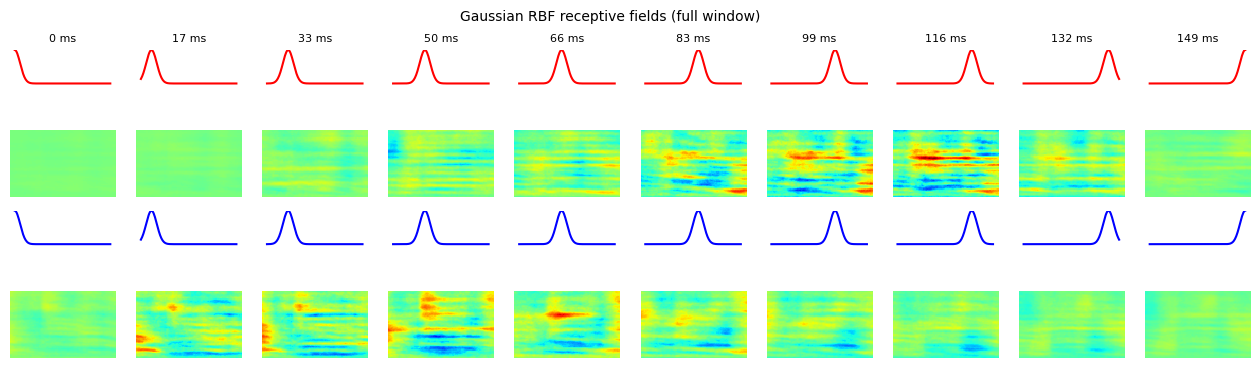

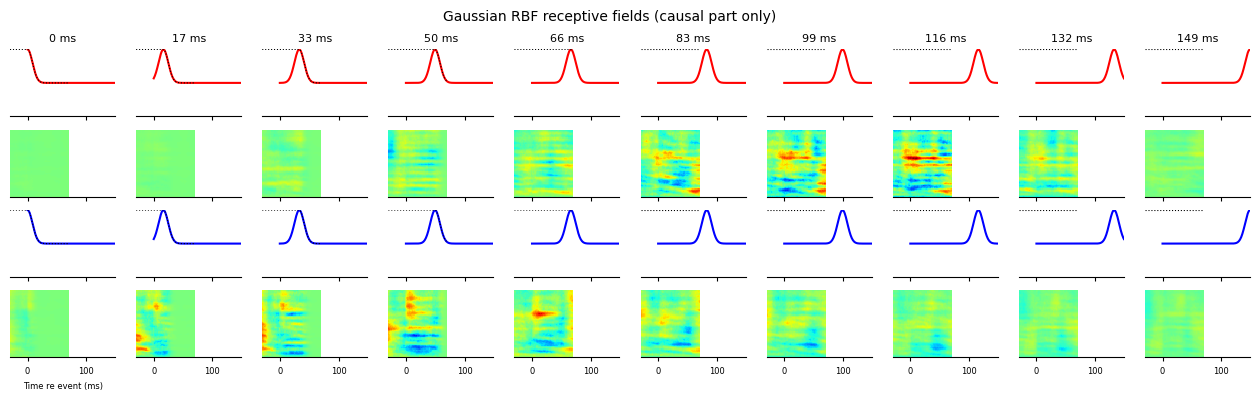

In [56]:
# Change of basis: Laguerre -> Gaussian radial basis functions
#
# In the Laguerre model the contribution of an onset event to the response at lag t is
#       K_on(f, tau, t) = sum_iL strfLGOn[iL, f, tau] * L_iL(t)
# where L_iL is the (L2 normalized) Laguerre basis used in the fit.  Because each L_iL
# spans the whole 0-nPoints range, the individual strfLGOn[iL] are hard to read.
# Here we re-express the same function of lag on a set of nGauss evenly spaced
# Gaussians G_j(t) that tile the same range,
#       K_on(f, tau, t) ~ sum_j strfRBFOn[j, f, tau] * G_j(t)
# so that strfRBFOn[j] is (up to the width of the Gaussian) the receptive field
# "seen" at lag gaussCenters[j] ms.  The change of basis is a least-squares projection:
# with L (nLaguerre x nPoints) and G (nGauss x nPoints) the two basis matrices, the
# best G-coefficients for anything in the row space of L come from T = L @ pinv(G),
# and the new weights are simply the old weights times T.

nGauss = 10
x_t = np.arange(nPoints)

# Gaussian basis - centers evenly spanning the lag range, sd = half the center spacing
gaussCenters = np.linspace(0, nPoints - 1, nGauss)
gaussSD = (gaussCenters[1] - gaussCenters[0]) / 2.0
gaussBasis = np.zeros((nGauss, nPoints))
for iG in range(nGauss):
    gaussBasis[iG, :] = calcSegmentedModel.Gauss(x_t, gaussCenters[iG], gaussSD)

# The Laguerre basis exactly as used in fit_seg (unit L2 norm)
lagBasisOn = np.zeros((nLaguerre, nPoints))
lagBasisOff = np.zeros((nLaguerre, nPoints))
for iL in range(nLaguerre):
    y = calcSegmentedModel.laguerre(x_t, amp=1.0, tau=laguerre_args[0, 0],
                                    alpha=laguerre_args[0, 1], xorder=iL)
    lagBasisOn[iL, :] = y / np.sqrt(np.sum(y**2))
    y = calcSegmentedModel.laguerre(x_t, amp=1.0, tau=laguerre_args[1, 0],
                                    alpha=laguerre_args[1, 1], xorder=iL)
    lagBasisOff[iL, :] = y / np.sqrt(np.sum(y**2))

# Change of basis matrices: nLaguerre x nGauss
gaussPinv = np.linalg.pinv(gaussBasis)          # nPoints x nGauss
TOn = lagBasisOn @ gaussPinv
TOff = lagBasisOff @ gaussPinv

# How much of each Laguerre basis function can the Gaussian basis actually capture?
veOn = 1.0 - np.sum((lagBasisOn - TOn @ gaussBasis)**2) / np.sum(lagBasisOn**2)
veOff = 1.0 - np.sum((lagBasisOff - TOff @ gaussBasis)**2) / np.sum(lagBasisOff**2)
print('Gaussian basis (nGauss=%d, sd=%.1f ms) captures %.1f%% of the On Laguerre basis '
      'and %.1f%% of the Off Laguerre basis' % (nGauss, gaussSD, 100*veOn, 100*veOff))

# Project the fitted weights (the Laguerre receptive fields) into the Gaussian basis
strfRBFOn = np.einsum('lj,lft->jft', TOn, strfLGOn)
strfRBFOff = np.einsum('lj,lft->jft', TOff, strfLGOff)

# Fraction of the full time-varying kernel preserved by the change of basis
KOn_lag = np.einsum('lft,lp->ftp', strfLGOn, lagBasisOn)
KOn_rbf = np.einsum('jft,jp->ftp', strfRBFOn, gaussBasis)
KOff_lag = np.einsum('lft,lp->ftp', strfLGOff, lagBasisOff)
KOff_rbf = np.einsum('jft,jp->ftp', strfRBFOff, gaussBasis)
print('Time-varying kernel preserved: On %.1f%%, Off %.1f%%' % (
    100*(1.0 - np.sum((KOn_lag - KOn_rbf)**2)/np.sum(KOn_lag**2)),
    100*(1.0 - np.sum((KOff_lag - KOff_rbf)**2)/np.sum(KOff_lag**2))))


# ---- Causal masking -------------------------------------------------------
# Column tau of the feature window sits at absolute time t_event - segmentBuffer + tau,
# while Gaussian j drives the response at absolute time t_event + gaussCenters[j].
# Causality therefore requires   tau <= gaussCenters[j] + segmentBuffer.
# We taper past that cutoff with the falling half of the same Gaussian (same sd), so
# the softness of the boundary matches the temporal blur of the basis function itself.
# A Gaussian centered beyond nt - segmentBuffer has its cutoff past the end of the
# window and so is left untouched.  This is a display mask on an already fitted model,
# not a refit - the fit did have access to the acausal columns.
nfW, ntW = strfRBFOn.shape[1], strfRBFOn.shape[2]
tau_ax = np.arange(ntW)

causalMask = np.ones((nGauss, ntW))
for iG in range(nGauss):
    tauCut = gaussCenters[iG] + segmentBuffer
    iAcausal = tau_ax > tauCut
    causalMask[iG, iAcausal] = calcSegmentedModel.Gauss(tau_ax[iAcausal], tauCut, gaussSD)

centerUntouched = ntW - 1 - segmentBuffer
nUntouched = np.sum(gaussCenters >= centerUntouched)
print('Causal mask: cutoff at tau = center + %d ms; %d of %d basis functions '
      '(centers >= %d ms) are left untouched' % (segmentBuffer, nUntouched, nGauss,
                                                 centerUntouched))

strfRBFOnCausal = strfRBFOn * causalMask[:, np.newaxis, :]
strfRBFOffCausal = strfRBFOff * causalMask[:, np.newaxis, :]


# ---- Plotting -------------------------------------------------------------
# For On and Off, each Gaussian basis function above its receptive field.  The columns
# are ordered in time - column j is the RF at lag gaussCenters[j] ms.  Both figures
# share the color scale of the unmasked weights so they can be compared directly.
maxSTRF = np.max((np.abs(strfRBFOn).max(), np.abs(strfRBFOff).max()))


def plot_rbf_rfs(rfOn, rfOff, figTitle, saveName, mask=None, timeAxis=False):
    """Plot the On/Off RBF receptive fields, one column per Gaussian basis function.

    With timeAxis=True every panel is put on the common lag axis of the basis
    functions, -segmentBuffer to nPoints-1 ms relative to the event.  The weight
    images then span only -segmentBuffer to nt-segmentBuffer of that axis, so a
    horizontal position means the same time in the basis rows and the weight rows.
    """
    xlimTime = (-segmentBuffer, nPoints - 1)
    xticksTime = [0, 100]
    # In lag coordinates the stimulus window runs from -segmentBuffer to nt-segmentBuffer
    rfExtent = [-segmentBuffer, ntW - segmentBuffer] if timeAxis else [0, ntW]

    def style_time_axis(ax, showLabels):
        ax.set_xlim(xlimTime)
        ax.set_xticks(xticksTime)
        ax.set_yticks([])
        for sp in ('top', 'right', 'left'):
            ax.spines[sp].set_visible(False)
        ax.tick_params(axis='x', labelsize=6, length=3)
        ax.set_xticklabels(['%d' % xt for xt in xticksTime] if showLabels else [],
                           fontsize=6)

    plt.figure(figsize=(16, 4), dpi=100)
    for iG in range(nGauss):
        ax = plt.subplot(4, nGauss, iG + 1)
        plt.plot(x_t, gaussBasis[iG, :], 'r')
        if mask is not None:
            plt.plot(tau_ax - segmentBuffer, mask[iG, :], 'k:', linewidth=0.8)
        plt.ylim((-1, 1))
        style_time_axis(ax, False) if timeAxis else plt.axis('off')
        plt.title('%.0f ms' % gaussCenters[iG], fontsize=8)

        ax = plt.subplot(4, nGauss, nGauss + iG + 1)
        plt.imshow(rfOn[iG, :, :],
                   extent=[rfExtent[0], rfExtent[1], tfrep['f'][0]*1e-3, tfrep['f'][-1]*1e-3],
                   aspect='auto', interpolation='nearest', origin='lower', cmap='jet',
                   vmin=-maxSTRF, vmax=maxSTRF)
        style_time_axis(ax, False) if timeAxis else plt.axis('off')

        ax = plt.subplot(4, nGauss, 2*nGauss + iG + 1)
        plt.plot(x_t, gaussBasis[iG, :], 'b')
        if mask is not None:
            plt.plot(tau_ax - segmentBuffer, mask[iG, :], 'k:', linewidth=0.8)
        plt.ylim((-1, 1))
        style_time_axis(ax, False) if timeAxis else plt.axis('off')

        ax = plt.subplot(4, nGauss, 3*nGauss + iG + 1)
        plt.imshow(rfOff[iG, :, :],
                   extent=[rfExtent[0], rfExtent[1], tfrep['f'][0]*1e-3, tfrep['f'][-1]*1e-3],
                   aspect='auto', interpolation='nearest', origin='lower', cmap='jet',
                   vmin=-maxSTRF, vmax=maxSTRF)
        if timeAxis:
            style_time_axis(ax, True)
            if iG == 0:
                ax.set_xlabel('Time re event (ms)', fontsize=6)
        else:
            plt.axis('off')

    plt.suptitle(figTitle, fontsize=10)
    plt.savefig(saveName, dpi=100)
    plt.show()


# Figure 1 - the full weights
plot_rbf_rfs(strfRBFOn, strfRBFOff, 'Gaussian RBF receptive fields (full window)',
             '/Users/frederictheunissen/Desktop/Gaussian_RFs.eps')

# Figure 2 - the causal part only, on a common lag axis.  The dotted curve on the basis
# rows is the causal mask, drawn in lag coordinates (tau - segmentBuffer), where it
# starts falling exactly at the center of its Gaussian.
plot_rbf_rfs(strfRBFOnCausal, strfRBFOffCausal,
             'Gaussian RBF receptive fields (causal part only)',
             '/Users/frederictheunissen/Desktop/Gaussian_RFs_causal.eps',
             mask=causalMask, timeAxis=True)


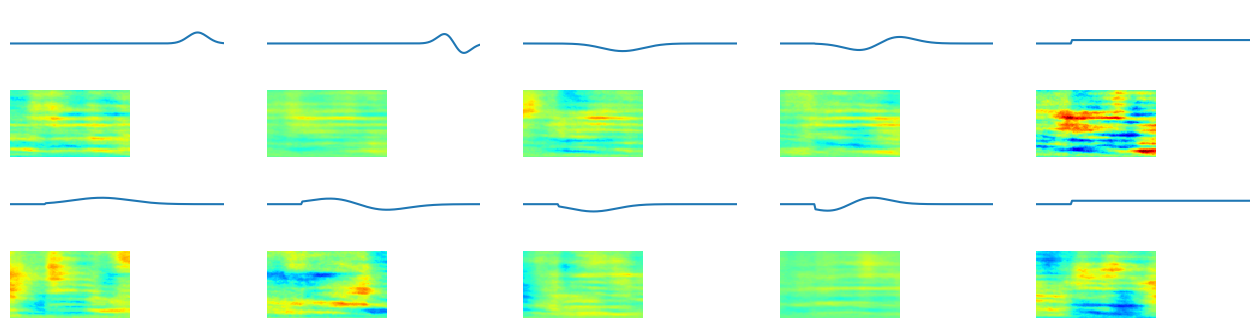

In [57]:
# Plot the On and Off filters for the DOGS Fit

plt.figure(figsize=(16, 4), dpi=100)
strfLGOn = np.zeros((nDOGS, nf, nt))
strfLGOff = np.zeros((nDOGS, nf, nt))
x_t = np.arange(nPoints)
x_plot = np.arange(nPoints+segmentBuffer)-segmentBuffer


for iD in range(nDOGS):
    istart = 2*npcs*iD
    iend = istart+npcs
    strfLGOn[iD,:,:] = np.dot(segIDModelDG['weights'][istart:iend], pca_spect.components_).reshape((nf,nt))
    strfLGOff[iD,:,:] = np.dot(segIDModelDG['weights'][istart+npcs:iend+npcs], pca_spect.components_).reshape((nf,nt))



maxSTRFOn = np.max((np.max(strfLGOn), np.abs(np.min(strfLGOn))))
maxSTRFOff = np.max((np.max(strfLGOff), np.abs(np.min(strfLGOff))))
maxSTRF = np.max((maxSTRFOn,maxSTRFOff))

meanValOn, ampPosOn, ampNegOn, tPosOn, tNegOn, sdPosOn, sdNegOn = DOGS_args[0]   
meanValOff, ampPosOff, ampNegOff, tPosOff, tNegOff, sdPosOff, sdNegOff = DOGS_args[1]                
for iD in range(nDOGS):
    yOn = np.zeros(nPoints+segmentBuffer) 
    yOff = np.zeros(nPoints+segmentBuffer)           
    if (iD == 0) :
        yOn[segmentBuffer:] = calcSegmentedModel.Gauss(x_t, tPosOn, sdPosOn)
        yOff[segmentBuffer:] = calcSegmentedModel.Gauss(x_t, tPosOff, sdPosOff)
    elif (iD == 1) : 
        yOn[segmentBuffer:] = calcSegmentedModel.DGauss(x_t, tPosOn, sdPosOn)
        yOff[segmentBuffer:] = calcSegmentedModel.DGauss(x_t, tPosOff, sdPosOff)
    elif (iD == 2) : 
        yOn[segmentBuffer:] = -calcSegmentedModel.Gauss(x_t, tNegOn, sdNegOn)
        yOff[segmentBuffer:] = -calcSegmentedModel.Gauss(x_t, tNegOff, sdNegOff)
    elif (iD ==3) :
        yOn[segmentBuffer:] = -calcSegmentedModel.DGauss(x_t, tNegOn, sdNegOn)
        yOff[segmentBuffer:] = -calcSegmentedModel.DGauss(x_t, tNegOff, sdNegOff)
    elif (iD == 4):
        yOn[segmentBuffer:] = np.ones(nPoints)
        yOff[segmentBuffer:] = np.ones(nPoints)
    
    yOn = yOn / np.sqrt(np.sum(yOn**2))
    yOff = yOff / np.sqrt(np.sum(yOff**2))

    plt.subplot(4,  nDOGS, iD+1)
    plt.plot(x_plot,yOn)
    plt.xlim([x_plot.min(), x_plot.max()])
    plt.ylim((-0.8,0.8))
    plt.axis('off')
    plt.subplot(4,  nDOGS, 2*nDOGS+iD+1)
    plt.plot(x_plot,yOff)
    plt.xlim([x_plot.min(), x_plot.max()])
    plt.ylim((-0.8,0.8))
    plt.axis('off')
    plt.subplot(4, nDOGS, nDOGS+iD+1)
    plt.imshow(strfLGOn[iD,:,:], extent=[-segmentBuffer, nt-segmentBuffer, tfrep['f'][0]*1e-3, tfrep['f'][-1]*1e-3],
                aspect='auto', interpolation='nearest', origin='lower', cmap='jet', vmin=-maxSTRF, vmax=maxSTRF)
    plt.xlim([x_plot.min(), x_plot.max()])
    plt.axis('off')
    plt.subplot(4, nDOGS, 3*nDOGS+iD+1)
    plt.imshow(strfLGOff[iD,:,:], extent=[-segmentBuffer, nt-segmentBuffer, tfrep['f'][0]*1e-3, tfrep['f'][-1]*1e-3],
                aspect='auto', interpolation='nearest', origin='lower', cmap='jet', vmin=-maxSTRF, vmax=maxSTRF)
    plt.xlim([x_plot.min(), x_plot.max()])
    plt.axis('off')
    plt.savefig('/Users/frederictheunissen/Desktop/DOGS_RFs.eps', dpi=100)



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


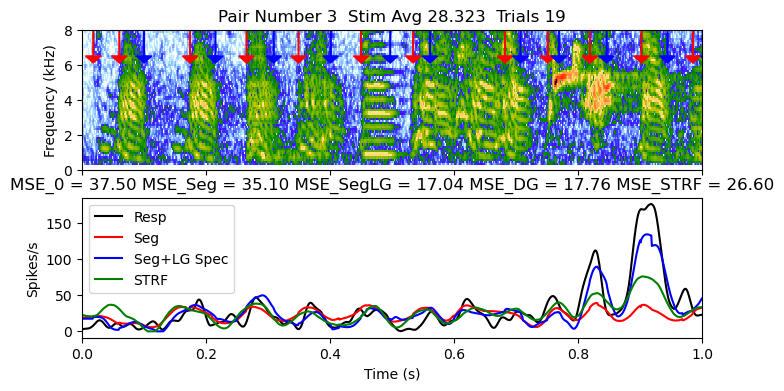

In [58]:
# Show all the results
DBNOISE = 80 # should match value in preprocSound
p = -1
gain = 1.0
ichoice = 3
for ipair, pair in enumerate(srData['datasets']):

    p += 1
    # Chose one
    if ichoice >= 0 and ipair != ichoice:
        continue

    # Get response (smoothed out psth)
    y = pair['resp']['psth_smooth']
    w = pair['resp']['weights']

    # Get stim and response used by the strf code
    srRange = np.where(globDat['groupIdx'] == p)[0]
    stim = globDat['stim'][srRange, :]
    ystrf = globDat['resp'][srRange]

    # Calculate the MSE for the average response and STRF model
    mse_0 = np.sqrt(np.sum(((y-segModel['yavg'])**2)*w)/np.sum(w))
    mse_0b = np.sqrt(np.sum(((ystrf-segModel['yavg'])**2)*w)/np.sum(w))

    # get the pred for the segmentation model
    x = calcSegmentedModel.generate_x(pair, event_types, xGen = 'Kernel', nPoints=nPoints)
    y_pred_1 = segModel['weights']@ (x - segModel['xavg']) + segModel['yavg']
    y_pred_1[y_pred_1<0] = 0.0
    mse_1 = np.sqrt(np.sum(((y-y_pred_1)**2)*w)/np.sum(w))
    mse_1b = np.sqrt(np.sum(((ystrf-y_pred_1)**2)*w)/np.sum(w))

    # get the pred for the two segmentation + identification models
    x = calcSegmentedModel.generate_x(pair, feature, basis_args = laguerre_args, xGen = 'LG', nPoints=nPoints, nLaguerre=nLaguerre)   
    y_pred_2 = gain*segIDModelLG['weights']@ (x - segIDModelLG['xavg']) + segIDModelLG['yavg'] + y_pred_1
    y_pred_2[y_pred_2<0] = 0.0
    mse_2 = np.sqrt(np.sum(((y-y_pred_2)**2)*w)/np.sum(w))
    mse_2b = np.sqrt(np.sum(((ystrf-y_pred_2)**2)*w)/np.sum(w))

    x = calcSegmentedModel.generate_x(pair, feature, basis_args = DOGS_args, xGen = 'DG', nPoints=nPoints, nLaguerre=nDOGS)   
    y_pred_3 = gain*segIDModelDG['weights']@ (x - segIDModelDG['xavg']) + segIDModelDG['yavg'] + y_pred_1
    y_pred_3[y_pred_3<0] = 0.0
    mse_3 = np.sqrt(np.sum(((y-y_pred_3)**2)*w)/np.sum(w))
    mse_3b = np.sqrt(np.sum(((ystrf-y_pred_3)**2)*w)/np.sum(w))

    # get the prediction for the classic STRF model
    gindx = np.ones((1, stim.shape[0]))

    y_pred_4 = trnDirectFit.conv_strf(stim-modelParams[0]['stimAvg'], modelParams[0]['delays'], np.real(modelParams[0]['w1']), gindx) + modelParams[0]['b1']
    y_pred_4[y_pred_4<0] = 0.0
    mse_4 = np.sqrt(np.sum(((y-y_pred_4)**2)*w)/np.sum(w))
    mse_4b = np.sqrt(np.sum(((ystrf-y_pred_4)**2)*w)/np.sum(w))

    # The spectrogram
    tfrep = pair['stim']['tfrep']
    minSpect = 0
    maxB = DBNOISE

    # Plot the spectrogram and the prediction
    f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=100, figsize = (8,4))
    cmap = plt.get_cmap('SpectroColorMap')
    ax1.imshow(tfrep['spec'], extent=[tfrep['t'][0], tfrep['t'][-1], tfrep['f'][0]*1e-3, tfrep['f'][-1]*1e-3],
                aspect='auto', interpolation='nearest', origin='lower', cmap=cmap, vmin=minSpect, vmax=maxB)
    ax1.set_ylim(0, 8)
    ax1.set_ylabel('Frequency (kHz)')
    ax1.set_title('Pair Number %d  Stim Avg %.3f  Trials %d' % (ipair, stim.mean(), w.max()))
    # Add arrows for the events
    events = pair['events']
    sampleRate = pair['stim']['sampleRate']
    for iEvent in range(events['index'].shape[0]):
        if events['onoff_feature'][iEvent][0] == 1:
            ax1.arrow(events['index'][iEvent]/sampleRate, 8, 0, -1.5, color='r', width=0.001, head_width=0.025, head_length=0.4)
        else:
            ax1.arrow(events['index'][iEvent]/sampleRate, 8, 0, -1.5, color='b', width=0.001, head_width=0.025, head_length=0.4)
    if ipair == ichoice:
        ax1.set_xlim(0, 1.0)
    
    # ax1.set_title('MSE_0 = %.2f MSE_Seg = %.2f MSE_SegLG = %.2f MSE_DG = %.2f MSE_STRF = %.2f' % (mse_0, mse_1, mse_2, mse_3, mse_4))
    # ax1.set_xlabel('Time (s)')

    # The prediction
    numTrials = len(pair['resp']['rawSpikeTimes'])
    # fac = pair['resp']['sampleRate']/numTrials   # The psth and the responses are already normalized in preprocSound.py
    ax2.plot(tfrep['t'], y, 'k', label='Resp')
    # ax2.plot(tfrep['t'], ystrf, 'k:', label='RespSTRF')
    ax2.plot(tfrep['t'], y_pred_1.T, 'r', label='Seg')
    ax2.plot(tfrep['t'], y_pred_2.T, 'b', label='Seg+LG Spec')
    # ax2.plot(tfrep['t'], y_pred_3.T, 'b:', label='Seg+DOGS Spec')
    ax2.plot(tfrep['t'], y_pred_4.T, 'g', label='STRF')
    # ax2.plot([tfrep['t'][0], tfrep['t'][-1]], [segModel['yavg'], segModel['yavg']], 'k--', label='Average' )
    ax2.set_ylabel('Spikes/s')
    ax2.set_xlabel('Time (s)')
    ax2.set_title('MSE_0 = %.2f MSE_Seg = %.2f MSE_SegLG = %.2f MSE_DG = %.2f MSE_STRF = %.2f' % (mse_0, mse_1, mse_2, mse_3, mse_4))
    if ipair == ichoice:
        ax2.set_xlim(0, 1.0)
    # ax2.set_title('MSE_0 = %.2f MSE_Seg = %.2f MSE_SegLG = %.2f MSE_DG = %.2f MSE_STRF = %.2f' % (mse_0b, mse_1b, mse_2b, mse_3b, mse_4b))
    plt.legend()
    if ipair == ichoice:  
        plt.savefig('/Users/frederictheunissen/Desktop/ExampleFit_pair_%d.eps' % (ipair), dpi=100)
        # break
    




Text(0, 0.5, 'R2')

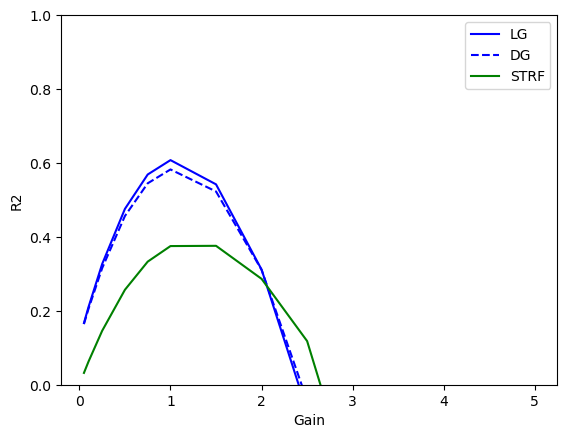

In [51]:
# Checking to make sure that the analytic gain from ridge equations is correct.
# if so, the maximum R2 should be at a gain of 1.0 (i.e. no gain)

# Show all the results
gainList = [0.05, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 5.0]
R2_SegLG = np.zeros(len(gainList))
R2_SegDG = np.zeros(len(gainList))
R2_STRF = np.zeros(len(gainList))

for gain in gainList:
    p = 0

sse_0 = 0
sse_1 = 0
s_w = 0
for pair in srData['datasets']:

    y = pair['resp']['psth_smooth']
    w = pair['resp']['weights']
    sse_0 += np.sum(((y-segModel['yavg'])**2)*w)
    s_w += np.sum(w)

    # get the pred for the segmentation model
    x = calcSegmentedModel.generate_x(pair, event_types, xGen = 'Kernel', nPoints=nPoints)
    y_pred_1 = segModel['weights']@ (x - segModel['xavg']) + segModel['yavg']
    y_pred_1[y_pred_1<0] = 0.0
    sse_1 = np.sum(((y-y_pred_1)**2)*w)

for ig, gain in enumerate(gainList):

    p = 0
    sse_2 = 0
    sse_3 = 0
    sse_4 = 0
    for pair in srData['datasets']:

        y = pair['resp']['psth_smooth']
        w = pair['resp']['weights']

        # get the pred for the segmentation model
        x = calcSegmentedModel.generate_x(pair, event_types, xGen = 'Kernel', nPoints=nPoints)
        y_pred_1 = segModel['weights']@ (x - segModel['xavg']) + segModel['yavg']

        # get the pred for the two segmentation + identification models
        x = calcSegmentedModel.generate_x(pair, feature, basis_args = laguerre_args, xGen = 'LG', nPoints=nPoints, nLaguerre=nLaguerre)   
        y_pred_2 = gain*segIDModelLG['weights']@ (x - segIDModelLG['xavg']) + segIDModelLG['yavg'] + y_pred_1
        y_pred_2[y_pred_2<0] = 0.0
        sse_2 += np.sum(((y-y_pred_2)**2)*w)

        x = calcSegmentedModel.generate_x(pair, feature, basis_args = DOGS_args, xGen = 'DG', nPoints=nPoints, nLaguerre=nDOGS)   
        y_pred_3 = gain*segIDModelDG['weights']@ (x - segIDModelDG['xavg']) + segIDModelDG['yavg'] + y_pred_1
        y_pred_3[y_pred_3<0] = 0.0
        sse_3 += np.sum(((y-y_pred_3)**2)*w)

        # get the prediction for the classic STRF model
        srRange = np.where(globDat['groupIdx'] == p)[0]
        p += 1
        stim = globDat['stim'][srRange, :] - modelParams[0]['stimAvg']
        gindx = np.ones((1, stim.shape[0]))

        #compute the prediction for the held out stimulus
        y_pred_4 = gain*trnDirectFit.conv_strf(stim, modelParams[0]['delays'], np.real(modelParams[0]['w1']), gindx) + modelParams[0]['b1']
        y_pred_4[y_pred_4<0] = 0.0
        sse_4 += np.sum(((y-y_pred_4)**2)*w)
    
    R2_SegLG[ig] = 1 - sse_2/sse_0
    R2_SegDG[ig] = 1 - sse_3/sse_0
    R2_STRF[ig] = 1 - sse_4/sse_0

plt.plot(np.array(gainList), R2_SegLG, 'b-', label='LG')
plt.plot(np.array(gainList), R2_SegDG, 'b--', label='DG')
plt.plot(np.array(gainList), R2_STRF, 'g-', label='STRF')
plt.ylim((0, 1.0))
plt.legend()
plt.xlabel('Gain')
plt.ylabel('R2')


